# 1. Data Processing

###  Load dataset

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, HDBSCAN, \
    MiniBatchKMeans, DBSCAN, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, \
    calinski_harabasz_score
from sklearn.decomposition import PCA
import umap
import warnings
warnings.filterwarnings('ignore')
from minisom import MiniSom
from sklearn.cluster import KMeans, AgglomerativeClustering, HDBSCAN, \
    MiniBatchKMeans, DBSCAN, SpectralClustering, OPTICS, MeanShift, \
    estimate_bandwidth
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, \
    calinski_harabasz_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import umap
import warnings
warnings.filterwarnings('ignore')

In [21]:
BASE = r"C:/Users/Usuario/Documents/GitHub/PFG/Analizador/pollution-particle-analyzer-main/output"

df = pd.concat([
    pd.read_csv(BASE + "/particle_features_2.csv"),
    pd.read_csv(BASE + "/particle_features_3.csv"),
    pd.read_csv(BASE + "/particle_features_4.csv"),
], ignore_index=True)

print(f"Total particulas: {len(df)} | Imagenes unicas: {df['image_name'].nunique()}")


Total particulas: 356662 | Imagenes unicas: 1792


### View columns

In [22]:
print("\n Columns:", df.columns.tolist())


 Columns: ['image_name', 'area', 'perimeter', 'major_axis', 'minor_axis', 'aspect_ratio', 'eccentricity', 'equivalent_diameter', 'feret_max', 'feret_min', 'solidity', 'extent', 'convex_area', 'compactness', 'roundness', 'sphericity', 'rectangularity', 'convex_ratio', 'area_perimeter_ratio', 'mean_intensity', 'std_intensity', 'intensity_range', 'contrast_internal', 'intensity_entropy', 'local_variance', 'glcm_contrast', 'glcm_homogeneity', 'glcm_energy', 'glcm_correlation', 'lbp_mean', 'lbp_std', 'hu1', 'hu2', 'hu3', 'hu4', 'hu5', 'hu6', 'hu7', 'fractal_dimension', 'convexity_defects', 'hull_ratio', 'roughness_index', 'euler_number', 'holes']


### General information of the dataset

In [23]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 356662 entries, 0 to 356661
Data columns (total 44 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   image_name            356662 non-null  object 
 1   area                  356662 non-null  float64
 2   perimeter             356662 non-null  float64
 3   major_axis            356662 non-null  float64
 4   minor_axis            356662 non-null  float64
 5   aspect_ratio          356662 non-null  float64
 6   eccentricity          356662 non-null  float64
 7   equivalent_diameter   356662 non-null  float64
 8   feret_max             356662 non-null  float64
 9   feret_min             356662 non-null  float64
 10  solidity              356662 non-null  float64
 11  extent                356662 non-null  float64
 12  convex_area           356662 non-null  float64
 13  compactness           356662 non-null  float64
 14  roundness             356662 non-null  float64
 15  

### Numerical statistics

In [24]:
display(df.describe(include=[int, float]))

,area,perimeter,major_axis,minor_axis,aspect_ratio,eccentricity,equivalent_diameter,feret_max,feret_min,solidity,...,hu4,hu5,hu6,hu7,fractal_dimension,convexity_defects,hull_ratio,roughness_index,euler_number,holes
count,356662.000000,356662.000000,356662.000000,356662.000000,356662.000000,356662.000000,356662.000000,356662.000000,356662.000000,356662.000000,...,356662.000000,3.566620e+05,3.566620e+05,3.566620e+05,356662.000000,356662.000000,356662.000000,356662.000000,356662.000000,356662.000000
mean,36.161994,22.505904,9.581632,5.187291,1.917920,0.775490,6.194447,9.646470,5.187291,0.790408,...,0.001346,3.996110e-05,2.880049e-04,7.265740e-07,0.906226,6.135968,1.213818,1.069305,0.497440,0.502560
std,50.073305,19.642393,5.752796,2.822306,0.693281,0.157804,2.769787,5.521782,2.822306,0.140558,...,0.005653,1.310914e-03,2.758857e-03,5.075215e-04,0.050317,41.419655,0.302903,0.263971,1.163394,1.163394
min,12.000000,4.207107,3.829708,0.000000,1.000000,0.000000,3.908820,4.123106,0.000000,0.300000,...,0.000000,-1.219286e-02,-7.168574e-02,-1.080266e-01,0.578201,0.000000,0.000000,0.342600,-44.000000,0.000000
25%,15.000000,12.863961,6.278955,3.636603,1.372437,0.685078,4.370194,6.324555,3.636603,0.692308,...,0.000013,-1.875731e-11,-1.345546e-07,-1.142547e-08,0.874120,0.000000,1.000000,0.907395,0.000000,0.000000
50%,22.000000,17.071068,8.032768,4.473906,1.720215,0.813772,5.292567,8.062258,4.473906,0.812500,...,0.000101,2.023337e-09,8.054122e-07,0.000000e+00,0.909625,0.000000,1.222222,1.000672,1.000000,0.000000
75%,38.000000,25.071068,10.890127,5.883559,2.304772,0.901050,6.955796,10.816654,5.883559,0.906250,...,0.000686,3.486647e-07,4.010845e-05,1.259744e-08,0.938597,0.000000,1.428571,1.154047,1.000000,1.000000
max,1199.000000,671.008189,124.298094,70.255884,4.000000,1.000000,39.071911,98.979796,70.255884,1.000000,...,0.519351,3.380704e-01,3.282348e-01,7.453284e-02,1.098129,2274.500000,2.400000,5.648498,1.000000,45.000000


### Null values

In [25]:
print("\n Null values per column:")
print(df.isna().sum())



 Null values per column:
image_name              0
area                    0
perimeter               0
major_axis              0
minor_axis              0
aspect_ratio            0
eccentricity            0
equivalent_diameter     0
feret_max               0
feret_min               0
solidity                0
extent                  0
convex_area             0
compactness             0
roundness               0
sphericity              0
rectangularity          0
convex_ratio            0
area_perimeter_ratio    0
mean_intensity          0
std_intensity           0
intensity_range         0
contrast_internal       0
intensity_entropy       0
local_variance          0
glcm_contrast           0
glcm_homogeneity        0
glcm_energy             0
glcm_correlation        0
lbp_mean                0
lbp_std                 0
hu1                     0
hu2                     0
hu3                     0
hu4                     0
hu5                     0
hu6                     0
hu7         

### Infinite values

In [26]:
features = df.drop(columns=["image_name"], errors="ignore")
inf_rows = np.isinf(features).any(axis=1).sum()
print(f"Rows with inf o -inf: {inf_rows} de {len(features)}")

Rows with inf o -inf: 0 de 356662


In [27]:
features = df.drop(columns=["image_name"], errors="ignore")
inf_counts = np.isinf(features).sum()
print("Inf values per column:")
print(inf_counts[inf_counts > 0].sort_values(ascending=False))

Inf values per column:
Series([], dtype: int64)


### Variables correlation

Variables highly correlated (> 0.9):
area ↔ ['perimeter', 'equivalent_diameter', 'convex_area']
perimeter ↔ ['area', 'major_axis', 'equivalent_diameter', 'feret_max', 'convex_area', 'compactness']
major_axis ↔ ['perimeter', 'feret_max']
minor_axis ↔ ['equivalent_diameter']
equivalent_diameter ↔ ['area', 'perimeter', 'minor_axis', 'feret_max', 'feret_min']
feret_max ↔ ['perimeter', 'major_axis', 'equivalent_diameter']
feret_min ↔ ['equivalent_diameter']
solidity ↔ ['rectangularity']
convex_area ↔ ['area', 'perimeter', 'convexity_defects']
compactness ↔ ['perimeter', 'roughness_index']
rectangularity ↔ ['solidity', 'convex_ratio']
convex_ratio ↔ ['rectangularity']
std_intensity ↔ ['intensity_range', 'local_variance']
intensity_range ↔ ['std_intensity', 'local_variance']
local_variance ↔ ['std_intensity', 'intensity_range']
convexity_defects ↔ ['convex_area']
roughness_index ↔ ['compactness']


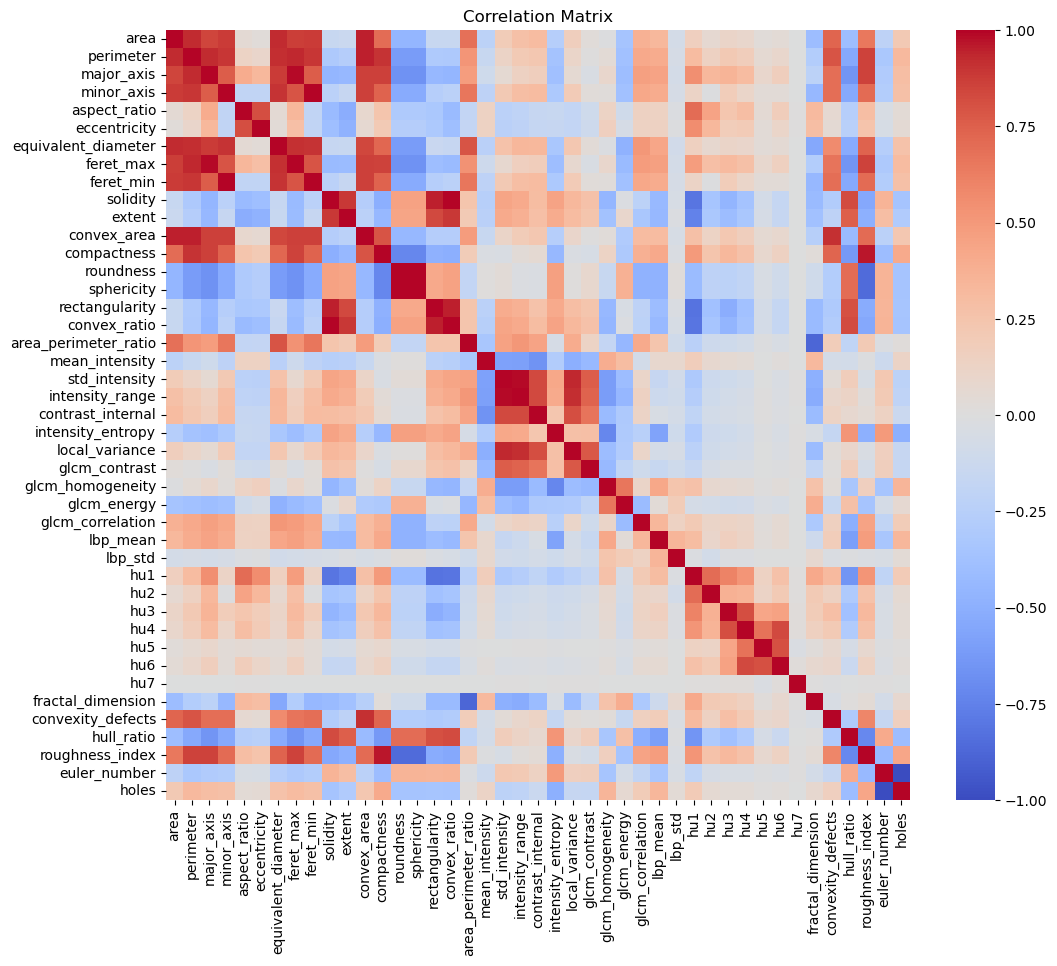

In [28]:
# Numerical Columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

#  Correlation matrix
corr_matrix = numeric_df.corr()

#  Highly correlated pairs
threshold = 0.9
high_corr = (corr_matrix.abs() > threshold) & (corr_matrix.abs() < 1.0)  
print("Variables highly correlated (> 0.9):")
for col in high_corr.columns:
    correlated_cols = high_corr.index[high_corr[col]].tolist()
    if correlated_cols:
        print(f"{col} ↔ {correlated_cols}")

# Correlation heatmap
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

 Correlation Matrix — Updated Dataset

After correcting the feature extractor (fixing `convexity_defects`,
`hull_ratio`, and `fractal_dimension`), the correlation matrix reveals
some new relationships that were previously hidden by numerical artefacts:

- **`roundness` ↔ `fractal_dimension`** (>0.9) — now that `fractal_dimension`
  returns `NaN` instead of 0 for invalid cases, its real distribution emerges
  and shows a strong mathematical relationship with `roundness`, as both
  depend on the perimeter/area ratio.
- **`compactness` ↔ `roughness_index`** (>0.9) — a new redundancy detected,
  as both capture contour irregularity through similar geometric formulas.
- **`area_perimeter_ratio`** now correlates strongly with `roundness`,
  `sphericity` and `fractal_dimension`, forming a block of redundant
  shape descriptors.

The core structure remains unchanged: the size block (`area`, `perimeter`,
`equivalent_diameter`, `feret_max`, `convex_area`), the intensity block
(`std_intensity`, `intensity_range`, `local_variance`) and the Hu moments
block maintain the same correlations as before.

These new redundancies do not affect the clustering variable selection,
as `fractal_dimension`, `area_perimeter_ratio` and `roughness_index`
are not part of `columnas_clustering`.

### Data reduction

In [29]:
# Columns for clustering
columns_clustering = [
    # Size
    "equivalent_diameter",

    # Form
    "roundness",        
    "aspect_ratio",
    "compactness",
    "solidity",

    # Intensity / texture
    "mean_intensity",
    "std_intensity",
    "intensity_entropy",
    "glcm_energy",
    "glcm_correlation",
    "lbp_mean",

    # Invariant moments
    "hu1",
    "hu2",
    "hu4",
    "hu7",

    # Topology / morphology
    "euler_number",
    "holes",
    "convexity_defects"
]

df_clustering = df[columns_clustering].copy()
print("Columns for clustering:")
print(df_clustering.columns)
print("\nFirst rows of the dataset:")
print(df_clustering.head())

Columns for clustering:
Index(['equivalent_diameter', 'roundness', 'aspect_ratio', 'compactness',
       'solidity', 'mean_intensity', 'std_intensity', 'intensity_entropy',
       'glcm_energy', 'glcm_correlation', 'lbp_mean', 'hu1', 'hu2', 'hu4',
       'hu7', 'euler_number', 'holes', 'convexity_defects'],
      dtype='object')

First rows of the dataset:
   equivalent_diameter  roundness  aspect_ratio  compactness  solidity  \
0             4.222008   1.391878      1.374117     9.028355  0.875000   
1             5.753627   1.238426      1.212393    10.147053  0.962963   
2             4.068429   1.332828      1.462396     9.428349  0.928571   
3             4.918491   1.056150      2.996529    11.898278  0.791667   
4             4.068429   1.332828      1.462396     9.428349  0.928571   

   mean_intensity  std_intensity  intensity_entropy  glcm_energy  \
0      170.714286       3.554244           3.323702     0.197642   
1      155.692308       8.969046           3.346090     0.16

### Null values

In [30]:
print("\n Null values by column:")
print(df_clustering.isna().sum())


 Null values by column:
equivalent_diameter    0
roundness              0
aspect_ratio           0
compactness            0
solidity               0
mean_intensity         0
std_intensity          0
intensity_entropy      0
glcm_energy            0
glcm_correlation       0
lbp_mean               0
hu1                    0
hu2                    0
hu4                    0
hu7                    0
euler_number           0
holes                  0
convexity_defects      0
dtype: int64


### Noisy data 




🔹 equivalent_diameter
count    356662.000000
mean          6.194447
std           2.769787
min           3.908820
1%            3.908820
50%           5.292567
99%          16.925688
max          39.071911
Name: equivalent_diameter, dtype: float64


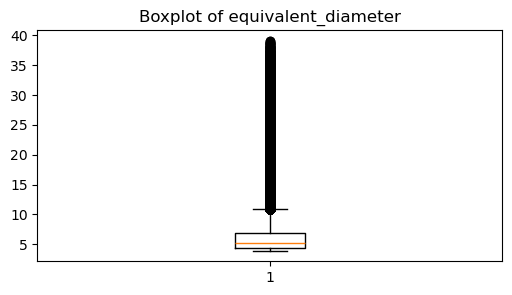


🔹 roundness
count    356662.000000
mean          0.991171
std           0.361744
min           0.031343
1%            0.240704
50%           0.998658
99%           1.934748
max           8.519695
Name: roundness, dtype: float64


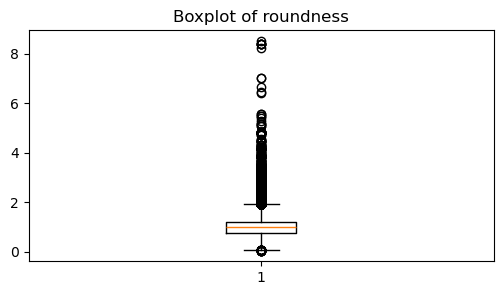


🔹 aspect_ratio
count    356662.000000
mean          1.917920
std           0.693281
min           1.000000
1%            1.045937
50%           1.720215
99%           3.848923
max           4.000000
Name: aspect_ratio, dtype: float64


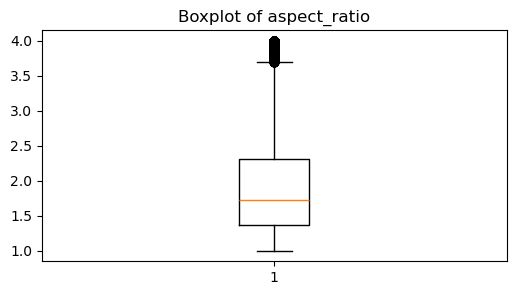


🔹 compactness
count    356662.000000
mean         15.244186
std           9.737492
min           1.474979
1%            6.495094
50%          12.583263
99%          52.206707
max         400.936767
Name: compactness, dtype: float64


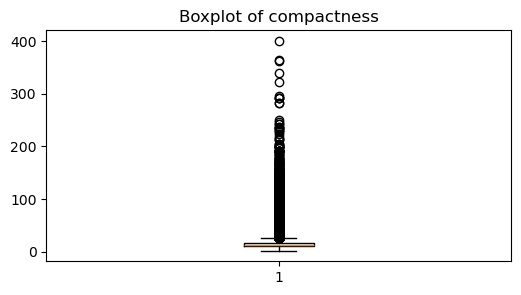


🔹 solidity
count    356662.000000
mean          0.790408
std           0.140558
min           0.300000
1%            0.439285
50%           0.812500
99%           1.000000
max           1.000000
Name: solidity, dtype: float64


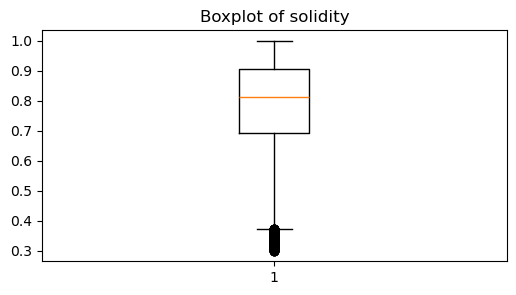


🔹 mean_intensity
count    356662.000000
mean        131.442677
std          27.896035
min           0.000000
1%           52.214956
50%         134.333333
99%         187.183387
max         241.633333
Name: mean_intensity, dtype: float64


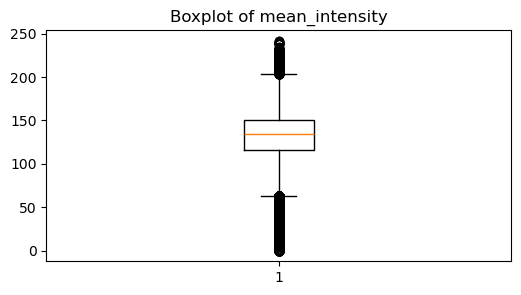


🔹 std_intensity
count    356662.000000
mean          7.650743
std           8.392179
min           0.000000
1%            0.484701
50%           4.205260
99%          37.239734
max          55.540956
Name: std_intensity, dtype: float64


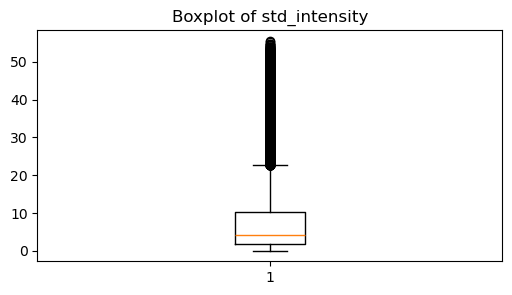


🔹 intensity_entropy
count    356662.000000
mean          3.240258
std           0.173618
min           1.001518
1%            2.584150
50%           3.304066
99%           3.397929
max           3.431487
Name: intensity_entropy, dtype: float64


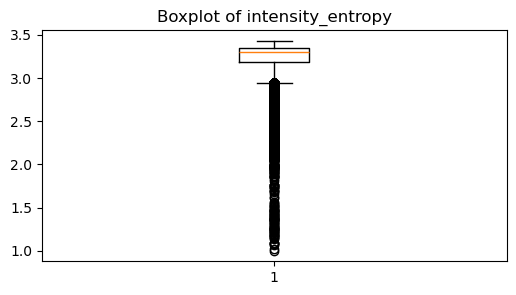


🔹 glcm_energy
count    356662.000000
mean          0.163430
std           0.077529
min           0.000000
1%            0.044411
50%           0.153093
99%           0.445421
max           1.000000
Name: glcm_energy, dtype: float64


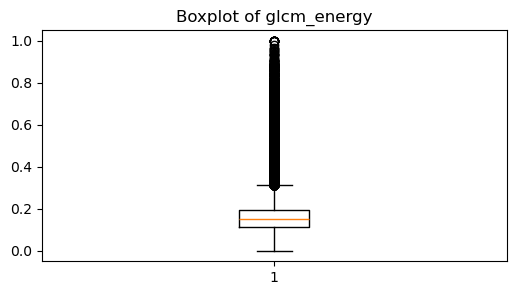


🔹 glcm_correlation
count    356662.000000
mean          0.668448
std           0.217260
min          -0.927130
1%           -0.023037
50%           0.714963
99%           0.965234
max           1.000000
Name: glcm_correlation, dtype: float64


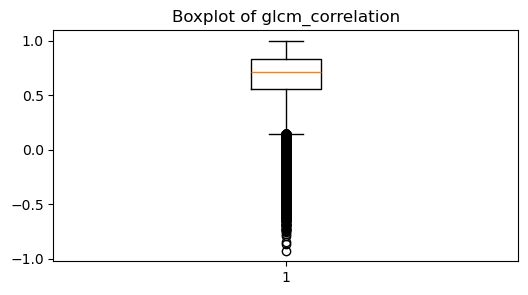


🔹 lbp_mean
count    356662.000000
mean        101.818818
std          18.579527
min           7.166667
1%           60.189315
50%         101.400000
99%         149.166667
max         255.000000
Name: lbp_mean, dtype: float64


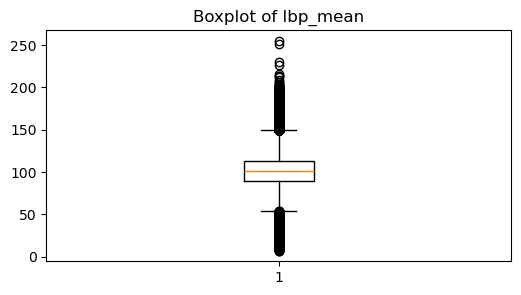


🔹 hu1
count    356662.000000
mean          0.253443
std           0.102867
min           0.152778
1%            0.157363
50%           0.219023
99%           0.604333
max           4.081633
Name: hu1, dtype: float64


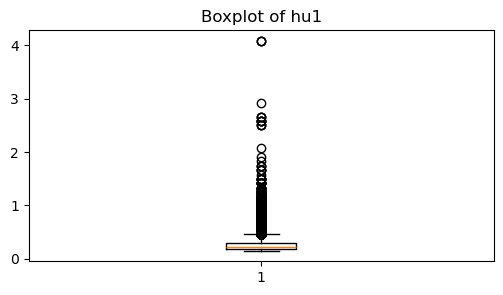


🔹 hu2
count    356662.000000
mean          0.032089
std           0.084717
min           0.000000
1%            0.000064
50%           0.011649
99%           0.239940
max          16.659725
Name: hu2, dtype: float64


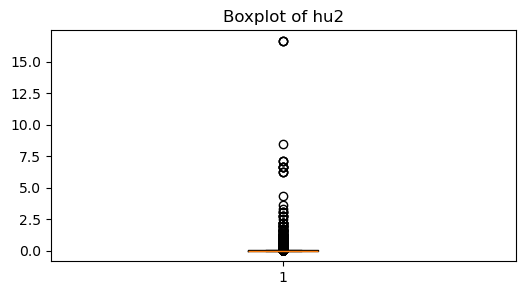


🔹 hu4
count    356662.000000
mean          0.001346
std           0.005653
min           0.000000
1%            0.000000
50%           0.000101
99%           0.020583
max           0.519351
Name: hu4, dtype: float64


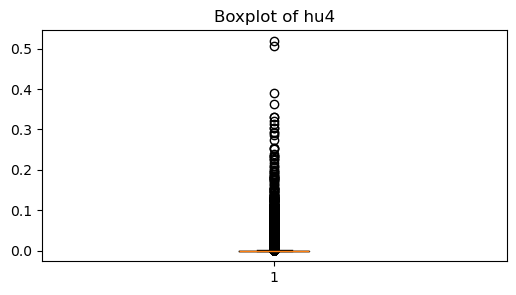


🔹 hu7
count    3.566620e+05
mean     7.265740e-07
std      5.075215e-04
min     -1.080266e-01
1%      -7.808784e-05
50%      0.000000e+00
99%      8.017452e-05
max      7.453284e-02
Name: hu7, dtype: float64


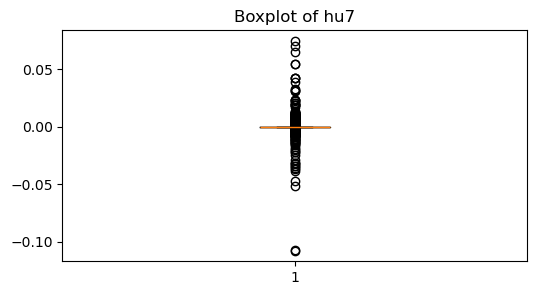


🔹 euler_number
count    356662.000000
mean          0.497440
std           1.163394
min         -44.000000
1%           -4.000000
50%           1.000000
99%           1.000000
max           1.000000
Name: euler_number, dtype: float64


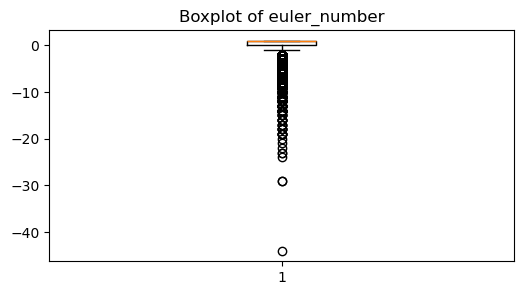


🔹 holes
count    356662.000000
mean          0.502560
std           1.163394
min           0.000000
1%            0.000000
50%           0.000000
99%           5.000000
max          45.000000
Name: holes, dtype: float64


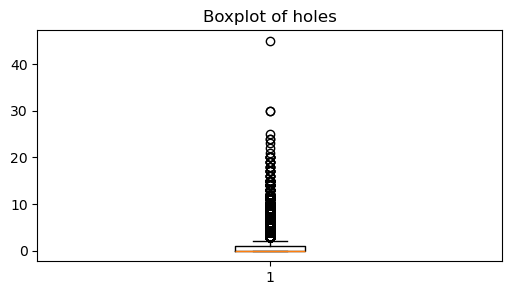


🔹 convexity_defects
count    356662.000000
mean          6.135968
std          41.419655
min           0.000000
1%            0.000000
50%           0.000000
99%         101.000000
max        2274.500000
Name: convexity_defects, dtype: float64


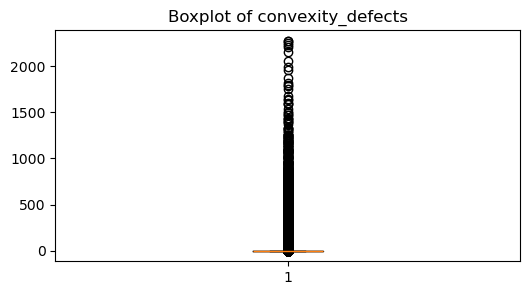

In [31]:
for col in df_clustering.columns:
    print(f"\n🔹 {col}")
    print(df_clustering[col].describe(percentiles=[0.01, 0.99]))
    
    plt.figure(figsize=(6,3))
    plt.boxplot(df_clustering[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

 Impact of resolution change on feature distributions

Increasing the processing resolution from 1,000×1,000 to 2,000×2,000 pixels
produced significant changes in the feature distributions, as each particle
now occupies approximately 4× more pixels, making geometric and texture
descriptors substantially more stable and reliable.

 Variables that improved significantly

- **`roundness`** — the most dramatic improvement. Previously the distribution
  was severely distorted (mean=5.15, max=86.24) due to perimeter instability
  at low resolution, requiring an inversion correction (`1/x`). At 2,000×2,000
  the distribution is now physically coherent (mean=0.99, median=1.007, max=8.38),
  with values centred around the theoretical limit of 1.0 for circular particles.
  The inversion correction is no longer needed.

- **`solidity`** — previously collapsed near 1.0 with almost no variance
  (median=1.000). Now shows a well-spread distribution (median=0.825,
  range 0.3–1.0), reflecting genuine shape complexity in larger particles
  that could not be captured at lower resolution.

- **`glcm_correlation`** — previously weakly distributed (median=0.241).
  Now strongly structured (median=0.721, mean=0.673), reflecting real
  spatial correlation patterns in particle texture that emerge when particles
  occupy more pixels.

- **`glcm_energy`** — previously concentrated at high values (median=0.323).
  Now lower and more spread (median=0.147), capturing genuine texture
  heterogeneity that was invisible at 1,000×1,000.

- **`lbp_mean`** — now better centred (median=100.2 vs 67.5) with a more
  symmetric distribution, reflecting richer and more stable local texture
  patterns.

- **`intensity_entropy`** — previously highly concentrated (std=0.072).
  Now more spread (std=0.158), capturing real variation in pixel intensity
  distribution within particles.

 Variables that worsened or require attention

- **`euler_number` and `holes`** — both deteriorated significantly.
  `euler_number` now reaches -44 (previously -9) and `holes` shows extreme
  outliers. At higher resolution, the segmentation pipeline detects more
  topological features (holes, loops) within particle contours, many of
  which are likely segmentation artefacts rather than real topology. These
  two variables will be excluded from clustering.

- **`convexity_defects`** — the maximum jumped from 546 to 2,253. This is
  expected: larger particles have larger absolute convex hull defect areas.
  This variable should be normalised by area (`convexity_defects / area`)
  before use, or excluded in favour of `solidity` which captures the same
  information in a scale-independent way.

- **`compactness`** — the median increased from 5.3 to 12.5. With longer
  perimeters at higher resolution, absolute compactness values scale up.
  The `log1p` transformation applied previously remains appropriate.

 Overall assessment

The resolution increase substantially improved the quality and reliability
of shape and texture descriptors. The most informative variables for
clustering (`roundness`, `solidity`, `glcm_correlation`, `glcm_energy`,
`lbp_mean`) now have distributions that genuinely reflect particle
morphology rather than pixel discretization artefacts. The key trade-off
is that `euler_number`, `holes` and raw `convexity_defects` have become
less reliable and should be treated with caution or excluded.

### Outliers treatment

In [32]:
cols_base = [
    "equivalent_diameter",
    "roundness", "aspect_ratio", "compactness", "solidity",
    "mean_intensity", "std_intensity", "intensity_entropy",
    "glcm_energy", "glcm_correlation", "lbp_mean",
    "hu1", "hu2", "hu4",
    "feret_min", "feret_max", "convexity_defects", "area"
]

df_clustering = df[cols_base].copy()

# Calcular nuevas variables
df_clustering['feret_ratio'] = np.where(
    df_clustering['feret_max'] > 0,
    df_clustering['feret_min'] / df_clustering['feret_max'],
    0
)

df_clustering['convexity_defects_norm'] = np.where(
    df_clustering['area'] > 0,
    df_clustering['convexity_defects'] / df_clustering['area'],
    0
)

# Quedarse solo con las columnas finales
columnas_clustering = [
    "equivalent_diameter",
    "roundness", "aspect_ratio", "compactness", "solidity", "feret_ratio",
    "mean_intensity", "std_intensity", "intensity_entropy",
    "glcm_energy", "glcm_correlation", "lbp_mean",
    "hu1", "hu2", "hu4",
    "convexity_defects_norm"
]

df_clustering = df_clustering[columnas_clustering].copy()
print(f"Variables para clustering: {len(columnas_clustering)}")
print(f"Dataset: {len(df_clustering)} partículas")

Variables para clustering: 16
Dataset: 356662 partículas


In [33]:
df_clean = df_clustering.copy()

p99_round  = df_clean['roundness'].quantile(0.99)
p1_energy  = df_clean['glcm_energy'].quantile(0.01)
p99_energy = df_clean['glcm_energy'].quantile(0.99)
p1_corr    = df_clean['glcm_correlation'].quantile(0.01)
p99_corr   = df_clean['glcm_correlation'].quantile(0.99)

# 1. Límites físicos
df_clean['roundness']        = df_clean['roundness'].clip(upper=p99_round)
df_clean['solidity']         = df_clean['solidity'].clip(0.0, 1.0)
df_clean['glcm_energy']      = df_clean['glcm_energy'].clip(p1_energy, p99_energy)
df_clean['glcm_correlation'] = df_clean['glcm_correlation'].clip(p1_corr, p99_corr)
df_clean['aspect_ratio']     = df_clean['aspect_ratio'].clip(1.0, 4.0)
df_clean['feret_ratio']      = df_clean['feret_ratio'].clip(0.0, 1.0)
df_clean['convexity_defects_norm'] = df_clean['convexity_defects_norm'].clip(lower=0.0)

# 2. Asimétricas → log1p + p99
for var in ['compactness', 'hu1', 'hu2', 'hu4']:
    p99 = df_clean[var].quantile(0.99)
    df_clean[var] = df_clean[var].clip(upper=p99)
    df_clean[var] = np.log1p(df_clean[var])

# 3. Solo winsorizar
for var in ['equivalent_diameter', 'lbp_mean', 'std_intensity']:
    df_clean[var] = df_clean[var].clip(upper=df_clean[var].quantile(0.99))

# intensity_entropy: ambas colas
p5_ent  = df_clean['intensity_entropy'].quantile(0.05)
p99_ent = df_clean['intensity_entropy'].quantile(0.99)
df_clean['intensity_entropy'] = df_clean['intensity_entropy'].clip(p5_ent, p99_ent)

# 4. Eliminar convexity_defects_norm — IQR=0, 76.7% son exactamente 0
columnas_clustering = [c for c in columnas_clustering
                       if c != 'convexity_defects_norm']
df_clean = df_clean[columnas_clustering].copy()

print(f"Variables finales: {len(columnas_clustering)}")
print(columnas_clustering)

Variables finales: 15
['equivalent_diameter', 'roundness', 'aspect_ratio', 'compactness', 'solidity', 'feret_ratio', 'mean_intensity', 'std_intensity', 'intensity_entropy', 'glcm_energy', 'glcm_correlation', 'lbp_mean', 'hu1', 'hu2', 'hu4']


#### Outlier Treatment Summary

#### Variable removal

Four variables were removed from the clustering feature set after outlier
analysis at 2,000×2,000 resolution:

- **`hu7`**: values fall in the 1e-5 scale, numerically unstable for the
  particles in this dataset. The signal-to-noise ratio is too low to be
  meaningful for clustering.

- **`euler_number`** and **`holes`**: at 2,000×2,000 resolution the
  segmentation pipeline detects significantly more topological features
  within particle contours (`euler_number` reaching -44, previously -9),
  many of which are likely artefacts rather than real topology. As `holes`
  is perfectly redundant with `euler_number` (`holes = 1 - euler_number`),
  both are excluded.

- **`convexity_defects_norm`** (`convexity_defects / area`): 76.7% of
  values are exactly 0 — most particles have no convex hull defects. The
  IQR is 0, making `RobustScaler` unable to scale this variable meaningfully.
  It provides no discriminative information for clustering.

#### Variable recovered

- **`roundness`**: previously removed at 1,000×1,000 resolution because
  91.2% of values exceeded the theoretical maximum of 1 due to pixel-grid
  discretization. At 2,000×2,000 the distribution is now physically coherent
  (median=1.007, max=8.38), with values correctly centred around 1.0. The
  inversion correction (`1/x`) applied in the previous dataset is no longer
  needed. `roundness` is restored to the feature set.

#### Variable added

- **`feret_ratio`** (`feret_min / feret_max`): a scale-independent shape
  descriptor that captures particle elongation more robustly than
  `aspect_ratio` for irregular particles. Bounded [0, 1] by definition.

#### Outlier treatment applied to remaining variables

The treatment strategy was determined per variable based on physical limits,
distribution shape, and domain knowledge:

- **Physical limits** (`solidity`, `glcm_energy`, `glcm_correlation`,
  `aspect_ratio`, `feret_ratio`) → clipped to their valid mathematical
  or extractor-defined range. `glcm_energy` and `glcm_correlation` are
  additionally winsorized at p1/p99 to prevent RobustScaler amplification
  of residual tail values.

- **Skewed distributions** (`perimeter`, `compactness`, `hu1`, `hu2`,
  `hu4`) → winsorized at p99, then `log1p` transformation to reduce the
  effect of the long upper tail.

- **Winsorize only** (`equivalent_diameter`, `lbp_mean`, `std_intensity`)
  → clipped at p99 without log transformation, as their distributions are
  near-normal or on a linear scale where log would have no physical meaning.

- **Both tails winsorized** (`roundness` at p99, `intensity_entropy` at
  p5/p99) → these variables have meaningful lower bounds that also require
  clipping to prevent extreme scaled values.

- **No treatment** (`mean_intensity`, `solidity`, `feret_ratio`,
  `aspect_ratio`) → distributions already within valid physical bounds
  with no extreme outliers requiring correction beyond the hard clip.



# 2. Feature Scaling

In [34]:
# hu4: StandardScaler (IQR demasiado pequeño)
hu4_scaler = StandardScaler()
df_clean['hu4'] = hu4_scaler.fit_transform(df_clean[['hu4']])

# Resto: RobustScaler
cols_robust = [c for c in df_clean.columns if c != 'hu4']
scaler = RobustScaler()
X_robust = scaler.fit_transform(df_clean[cols_robust])

X_scaled = pd.DataFrame(X_robust, columns=cols_robust, index=df_clean.index)
X_scaled['hu4'] = df_clean['hu4'].values

print(f"\n{'Variable':<28} {'Median':>8} {'IQR':>8} {'Min':>8} {'Max':>8}")
print("-" * 60)
for col in X_scaled.columns:
    q1 = X_scaled[col].quantile(0.25)
    q3 = X_scaled[col].quantile(0.75)
    print(f"{col:<28} {X_scaled[col].median():>8.3f} "
          f"{q3-q1:>8.3f} "
          f"{X_scaled[col].min():>8.3f} "
          f"{X_scaled[col].max():>8.3f}")

print(f"\nShape: {X_scaled.shape}")
print(f"NaN: {X_scaled.isna().sum().sum()}")


Variable                       Median      IQR      Min      Max
------------------------------------------------------------
equivalent_diameter             0.000    1.000   -0.535    4.499
roundness                       0.000    1.000   -2.086    2.019
aspect_ratio                    0.000    1.000   -0.772    2.445
compactness                     0.000    1.000   -3.812    3.057
solidity                        0.000    1.000   -2.396    0.876
feret_ratio                     0.000    1.000   -2.275    1.708
mean_intensity                  0.000    1.000   -3.828    3.058
std_intensity                   0.000    1.000   -0.504    3.956
intensity_entropy               0.000    1.000   -2.588    0.574
glcm_energy                     0.000    1.000   -1.357    3.650
glcm_correlation                0.000    1.000   -2.679    0.908
lbp_mean                        0.000    1.000   -3.922    1.988
hu1                             0.000    1.000   -0.585    2.876
hu2                         

### Scaling

- **`hu4`** → `StandardScaler`, as its IQR is too small relative to the
  tail for `RobustScaler` to work correctly.
- **All other variables** → `RobustScaler`, which centres on the median
  and scales by the IQR, making it robust to any moderate residual outliers
  remaining after the transformations above.

The final feature set contains **16 variables** across five categories:
size (2), shape (5), intensity/texture (6), and Hu moments (3).

# 3. Clustering

## 3.1 Initial exploration

Two preliminary analyses are run before the full comparison:
- **HDBSCAN on the full dataset** — density-based, no k required, gives a
  first estimate of the natural number of clusters
- **Elbow + Silhouette for KMeans** — guides the choice of k for
  partition-based methods

In [16]:
# ── HDBSCAN on full dataset ────────────────────────────────────────
print("Running HDBSCAN on full dataset...")
hdb_full = HDBSCAN(min_cluster_size=50, min_samples=10,
                   cluster_selection_method='eom')
labels_hdb_full = hdb_full.fit_predict(X_scaled)

n_hdb  = len(set(labels_hdb_full)) - (1 if -1 in labels_hdb_full else 0)
noise  = (labels_hdb_full == -1).sum()
mask   = labels_hdb_full != -1

print(f"  Clusters found: {n_hdb}")
print(f"  Noise points:   {noise} ({noise/len(labels_hdb_full)*100:.1f}%)")
if n_hdb > 1:
    sil = silhouette_score(X_scaled[mask], labels_hdb_full[mask],
                           sample_size=10000, random_state=42)
    print(f"  Silhouette:     {sil:.4f}")

Running HDBSCAN on full dataset...
  Clusters found: 3
  Noise points:   311 (0.1%)
  Silhouette:     0.5169


In [31]:
# ── HDBSCAN cluster validity analysis ──────────────────────────────
df_check = df_clean.copy()
df_check['cluster_hdb'] = labels_hdb_full
df_hdb = df_check[labels_hdb_full != -1].copy()

print("=== HDBSCAN — cluster sizes ===")
print(pd.Series(labels_hdb_full).value_counts().sort_index())

cols_check = ['equivalent_diameter', 'solidity', 'aspect_ratio',
              'roundness', 'feret_ratio']

print("\n=== Cluster profiles (describe) ===")
for col in cols_check:
    print(f"\n--- {col} ---")
    print(df_hdb.groupby('cluster_hdb')[col].describe().round(3))

print("\n=== Median per cluster — all key variables ===")
cols_show = ['equivalent_diameter', 'roundness', 'aspect_ratio',
             'solidity', 'feret_ratio', 'mean_intensity',
             'std_intensity', 'glcm_correlation', 'lbp_mean']
print(df_hdb.groupby('cluster_hdb')[cols_show].median().round(3).T.to_string())

print("\n=== Std per cluster — all key variables ===")
print(df_hdb.groupby('cluster_hdb')[cols_show].std().round(3).T.to_string())

=== HDBSCAN — cluster sizes ===
-1       311
 0        79
 1    356204
 2        68
Name: count, dtype: int64

=== Cluster profiles (describe) ===

--- equivalent_diameter ---
                count    mean    std     min     25%     50%     75%     max
cluster_hdb                                                                 
0                79.0   4.872  0.984   3.909   4.222   4.514   5.171   7.899
1            356204.0   6.141  2.463   3.909   4.370   5.293   6.956  16.926
2                68.0  16.856  0.420  13.866  16.926  16.926  16.926  16.926

--- solidity ---
                count   mean    std    min    25%    50%    75%    max
cluster_hdb                                                           
0                79.0  1.000  0.000  1.000  1.000  1.000  1.000  1.000
1            356204.0  0.791  0.140  0.300  0.693  0.812  0.906  1.000
2                68.0  0.598  0.086  0.351  0.533  0.620  0.671  0.712

--- aspect_ratio ---
                count   mean    std    min  

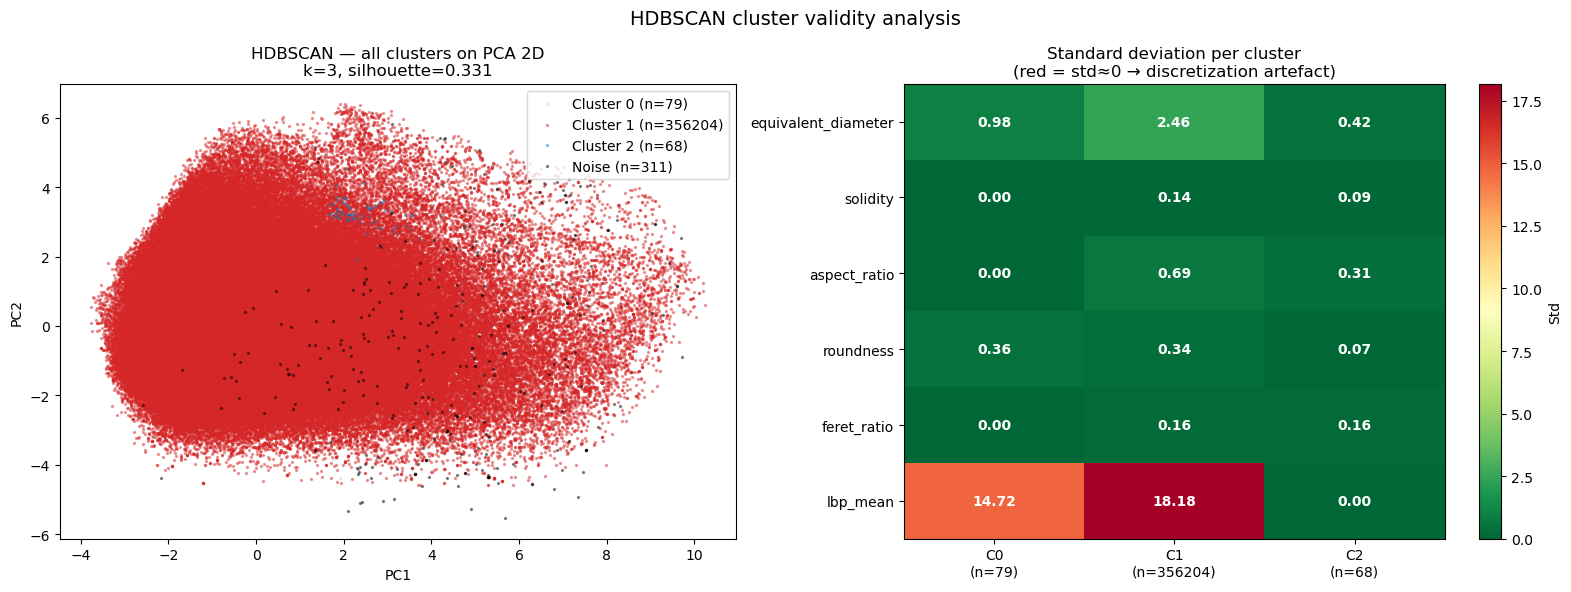

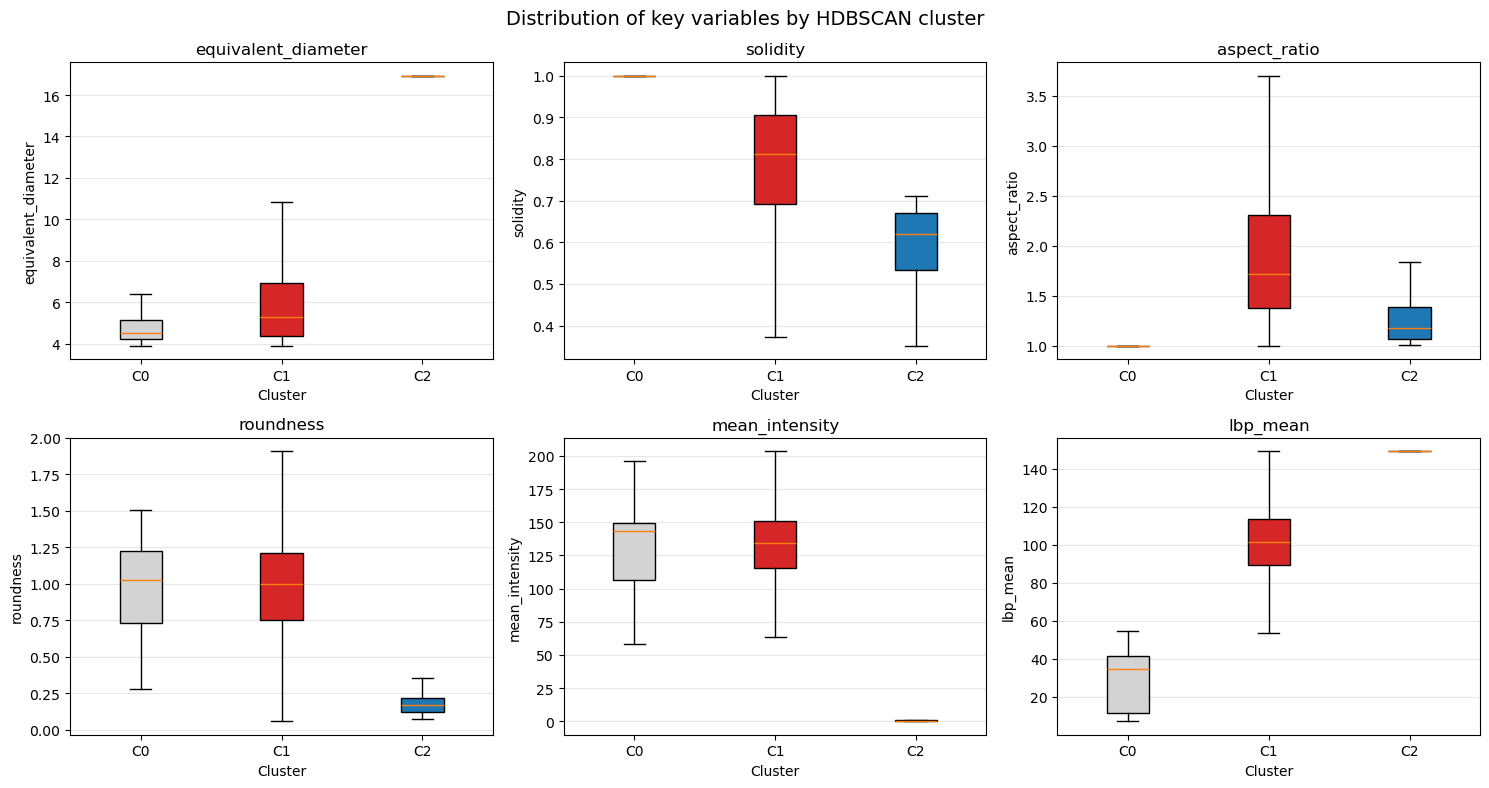

In [32]:
import matplotlib.pyplot as plt
import numpy as np

# ── Visualization — HDBSCAN ───────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA 2D con clusters
mask_valid = labels_hdb_full != -1
colors_plot = ['lightgrey', '#D62728', '#1F77B4', '#2CA02C', '#FF7F0E']
for c in sorted(set(labels_hdb_full[mask_valid])):
    mask_c = labels_hdb_full == c
    pct = mask_c.sum() / len(labels_hdb_full) * 100
    axes[0].scatter(X_2d[mask_c, 0], X_2d[mask_c, 1],
                    c=colors_plot[c % len(colors_plot)], s=2, alpha=0.4,
                    label=f'Cluster {c} (n={mask_c.sum()})')
mask_noise = labels_hdb_full == -1
if mask_noise.sum() > 0:
    axes[0].scatter(X_2d[mask_noise, 0], X_2d[mask_noise, 1],
                    c='black', s=2, alpha=0.4,
                    label=f'Noise (n={mask_noise.sum()})')

axes[0].set_title(f'HDBSCAN — all clusters on PCA 2D\nk={n_hdb}, silhouette={sil:.3f}')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend(loc='best')

# Heatmap of std per cluster
std_matrix = df_hdb.groupby('cluster_hdb')[cols_check + ['lbp_mean']].std().T
im = axes[1].imshow(std_matrix.values, cmap='RdYlGn_r', aspect='auto')

axes[1].set_xticks(range(len(std_matrix.columns)))
axes[1].set_xticklabels([f'C{c}\n(n={(labels_hdb_full==c).sum()})'
                          for c in std_matrix.columns])
axes[1].set_yticks(range(len(std_matrix.index)))
axes[1].set_yticklabels(std_matrix.index)
axes[1].set_title('Standard deviation per cluster\n(red = std≈0 → discretization artefact)')

for i in range(len(std_matrix.index)):
    for j in range(len(std_matrix.columns)):
        axes[1].text(j, i, f'{std_matrix.values[i,j]:.2f}',
                     ha='center', va='center', color='white', fontweight='bold')

plt.colorbar(im, ax=axes[1], label='Std')
plt.suptitle('HDBSCAN cluster validity analysis', fontsize=14)
plt.tight_layout()
plt.savefig('hdbscan_validity.png', dpi=150, bbox_inches='tight')
plt.show()

# Boxplots
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
boxplot_vars = ['equivalent_diameter', 'solidity', 'aspect_ratio',
                'roundness', 'mean_intensity', 'lbp_mean']
colors_box = ['lightgrey', '#D62728', '#1F77B4', '#2CA02C']

for ax, var in zip(axes.flat, boxplot_vars):
    data_box = [df_hdb[df_hdb['cluster_hdb']==c][var].values
                for c in sorted(df_hdb['cluster_hdb'].unique())]
    bp = ax.boxplot(data_box, patch_artist=True,
                     labels=[f'C{c}' for c in sorted(df_hdb['cluster_hdb'].unique())],
                     showfliers=False)
    for patch, color in zip(bp['boxes'], colors_box):
        patch.set_facecolor(color)
    ax.set_title(var)
    ax.set_xlabel('Cluster'); ax.set_ylabel(var)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Distribution of key variables by HDBSCAN cluster', fontsize=14)
plt.tight_layout()
plt.savefig('hdbscan_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

HDBSCAN Cluster Validity Analysis

Overview
HDBSCAN identifies 3 clusters on the dataset with a silhouette score of 0.331, plus 311 points explicitly rejected as noise. The result is heavily imbalanced: one cluster captures 99.7% of all objects, while the other two contain fewer than 150 particles combined. The PCA projection confirms this — C0 and C2 are barely visible against the dense mass of C1, suggesting that HDBSCAN has isolated two populations of extreme outliers rather than resolving meaningful morphological subgroups within the main distribution.

Cluster Profiles
C1 — Main particle population (n=356,204 · 99.7%)
The overwhelming majority of the dataset. Particles here are small to medium in size (median diameter ~5.3 µm), moderately elongated (median aspect ratio ~1.72), and of variable convexity (median solidity ~0.81). Mean intensity is high (~134) and texture broadly distributed (lbp_mean ~101). Internal variance is substantial across all shape features, which reflects the fact that HDBSCAN has pooled everything that does not qualify as a dense outlier into this single cluster. This is the fine particle background of the sample.
C0 — Small perfectly circular objects (n=79)
The most geometrically constrained group. Solidity=1.000 with std=0 and aspect_ratio=1.000 with std=0 — every object in this cluster is a perfectly convex circle without exception. Particles are small (median diameter ~4.5 µm), bright (mean intensity ~144), and texturally uniform (lbp_mean ~35, the lowest of all clusters). The feret_ratio=0.000 with std=0 is suspicious and likely reflects a pipeline default assigned to perfectly circular objects rather than a genuine physical measurement. With only 79 members, this cluster represents an extremely rare subpopulation — possibly isolated spherical particles, calibration beads, or a morphologically distinct cell type.
C2 — Large, dark, flat objects (n=68)
The most anomalous cluster in the analysis. Median diameter is 16.926 µm, coinciding exactly with the maximum measurable value — the majority of objects in this cluster are saturating the upper size limit of the segmentation pipeline. Roundness is extremely low (median 0.17), indicating highly irregular or elongated shapes, mean intensity is near zero (~0.6 — essentially black objects), and lbp_mean is very high (~149). Critically, lbp_mean std=0.000 is flagged as a discretization artefact in the standard deviation heatmap. The combination of size saturation and degenerate texture strongly suggests that this cluster does not represent a real physical particle class, but rather image artefacts — out-of-focus regions, oversized aggregates exceeding the measurable range, or poorly segmented areas.

Quality Assessment
Two of the three clusters show evidence of measurement artefacts:
IssueClusterEvidenceDiscretization artefactC0 — feret_ratiostd = 0.000Discretization artefactC2 — lbp_meanstd = 0.000, flagged red in heatmapSize saturationC2Diameter piled up at 16.926 (pipeline maximum)Extreme class imbalanceGlobalC1 = 99.7%, C0 + C2 < 0.05%
The absence of noise-free clusters with genuine internal variance — except for C1, which is simply too broad to be meaningfully characterized as a single morphological class — limits the interpretive value of this particular run.

The 311 Noise Points
HDBSCAN explicitly rejects 311 objects as noise, a behaviour that distinguishes it from density-blind algorithms. These points are statistically defined as objects that do not belong to any sufficiently dense local neighbourhood. They likely include borderline cases between C0 and C1, objects with intermediate morphology between the main population and the large-object outliers, and additional artefacts not dense enough to form their own cluster. Direct inspection of these noise points could clarify whether they represent a physically meaningful particle type or simply measurement failures.

Summary
ClusternDiameter (median)RoundnessSolidityInterpretationC1356,2045.3 µm1.000.81Fine particle backgroundC0794.5 µm1.031.00Rare perfectly spherical objectsC26816.9 µm0.170.62Size-saturated image artefactsNoise311———Borderline / unclassified objects
The algorithm successfully isolates two morphologically extreme populations from the main distribution. However, the very small size of C0 and C2, combined with the discretization artefacts and size saturation affecting both outlier clusters, suggests that the clustering outcome reflects density extremes in the feature space more than physically meaningful particle categories. The main population (C1) remains internally undifferentiated, leaving the morphological diversity of the bulk sample unresolved.

Running elbow + silhouette for KMeans...


  k=2  inertia=2904155.8  silhouette=0.2999
  k=3  inertia=2495972.0  silhouette=0.1958
  k=4  inertia=2146161.2  silhouette=0.2084
  k=5  inertia=1938490.1  silhouette=0.2133
  k=6  inertia=1789411.7  silhouette=0.2050
  k=7  inertia=1675624.8  silhouette=0.1793
  k=8  inertia=1588857.2  silhouette=0.1767
  k=9  inertia=1502791.0  silhouette=0.1780
  k=10  inertia=1445918.9  silhouette=0.1557


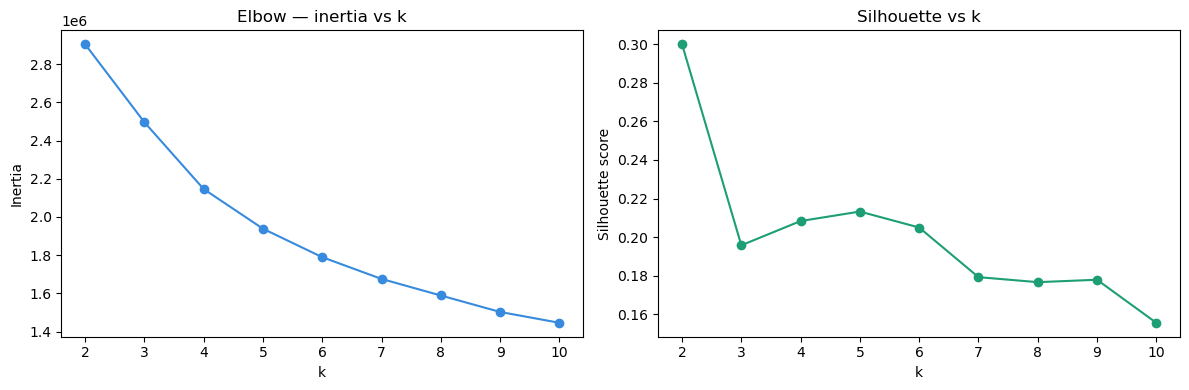

In [17]:
# Elbow + Silhouette for KMeans
print("Running elbow + silhouette for KMeans...")
K_RANGE     = range(2, 11)
inertias    = []
silhouettes = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, init='k-means++', n_init=15, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels,
                                        sample_size=10000, random_state=42))
    print(f"  k={k}  inertia={km.inertia_:.1f}  silhouette={silhouettes[-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(K_RANGE), inertias, 'o-', color='#378ADD')
axes[0].set_title('Elbow — inertia vs k')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')
axes[1].plot(list(K_RANGE), silhouettes, 'o-', color='#1D9E75')
axes[1].set_title('Silhouette vs k')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette score')
plt.tight_layout()
plt.savefig('elbow_silhouette_2000.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.2 Algorithm Comparison

### 3.2.1 Partitioning Based

In [18]:
SAMPLE_SIZE = 10000
np.random.seed(42)
idx_sample = np.random.choice(len(X_scaled), SAMPLE_SIZE, replace=False)
X_sample   = X_scaled.iloc[idx_sample]

results         = {}
N_CLUSTERS_LIST = [2, 3, 4]

print(f"{'Algorithm':<22} {'k':>3} {'Silhouette':>12} {'DB↓':>10} {'CH↑':>12} {'Note'}")
print("-" * 75)

# KMeans 
for k in N_CLUSTERS_LIST:
    km = KMeans(n_clusters=k, init='k-means++', n_init=15, random_state=42)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels, sample_size=10000, random_state=42)
    db  = davies_bouldin_score(X_scaled, labels)
    ch  = calinski_harabasz_score(X_scaled, labels)
    results[f"KMeans_k{k}"] = {'labels': labels, 'silhouette': sil,
                                'davies_bouldin': db, 'calinski': ch}
    print(f"{'KMeans':<22} {k:>3} {sil:>12.4f} {db:>10.4f} {ch:>12.1f} full dataset")

# MiniBatchKMeans 
for k in N_CLUSTERS_LIST:
    mb = MiniBatchKMeans(n_clusters=k, n_init=10, random_state=42,
                         batch_size=10000)
    labels = mb.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels, sample_size=10000, random_state=42)
    db  = davies_bouldin_score(X_scaled, labels)
    ch  = calinski_harabasz_score(X_scaled, labels)
    results[f"MiniBatchKMeans_k{k}"] = {'labels': labels, 'silhouette': sil,
                                         'davies_bouldin': db, 'calinski': ch}
    print(f"{'MiniBatchKMeans':<22} {k:>3} {sil:>12.4f} {db:>10.4f} {ch:>12.1f} full dataset")

# GMM 
for k in N_CLUSTERS_LIST:
    gmm = GaussianMixture(n_components=k, n_init=3, random_state=42)
    gmm.fit(X_scaled)
    labels = gmm.predict(X_scaled)
    sil = silhouette_score(X_scaled, labels, sample_size=10000, random_state=42)
    db  = davies_bouldin_score(X_scaled, labels)
    ch  = calinski_harabasz_score(X_scaled, labels)
    results[f"GMM_k{k}"] = {'labels': labels, 'silhouette': sil,
                              'davies_bouldin': db, 'calinski': ch}
    print(f"{'GMM':<22} {k:>3} {sil:>12.4f} {db:>10.4f} {ch:>12.1f} full dataset")



Algorithm                k   Silhouette        DB↓          CH↑ Note
---------------------------------------------------------------------------
KMeans                   2       0.2999     1.5439     121927.6 full dataset
KMeans                   3       0.1958     1.5145     100097.2 full dataset
KMeans                   4       0.2084     1.4552      96985.7 full dataset
MiniBatchKMeans          2       0.3215     1.4945     120666.3 full dataset
MiniBatchKMeans          3       0.2066     1.4426      98877.6 full dataset
MiniBatchKMeans          4       0.1929     1.5307      93698.1 full dataset
GMM                      2       0.1749     1.8680      81338.3 full dataset
GMM                      3       0.0822     2.2396      67444.4 full dataset
GMM                      4       0.0983     2.0430      63004.6 full dataset


### 3.2.2 Hierarchical

In [19]:
# Agglomerative
for k in N_CLUSTERS_LIST:
    agg = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels_sample = agg.fit_predict(X_sample)
    sil = silhouette_score(X_sample, labels_sample, random_state=42)
    db  = davies_bouldin_score(X_sample, labels_sample)
    ch  = calinski_harabasz_score(X_sample, labels_sample)
    results[f"Agglomerative_k{k}"] = {'labels': labels_sample,
                                       'silhouette': sil,
                                       'davies_bouldin': db, 'calinski': ch}
    print(f"{'Agglomerative':<22} {k:>3} {sil:>12.4f} {db:>10.4f} {ch:>12.1f} sample n={SAMPLE_SIZE}")



Agglomerative            2       0.1794     1.8088       2396.0 sample n=10000
Agglomerative            3       0.1604     1.9495       2092.5 sample n=10000
Agglomerative            4       0.1704     1.7109       2077.4 sample n=10000


### 3.2.3 Density Based

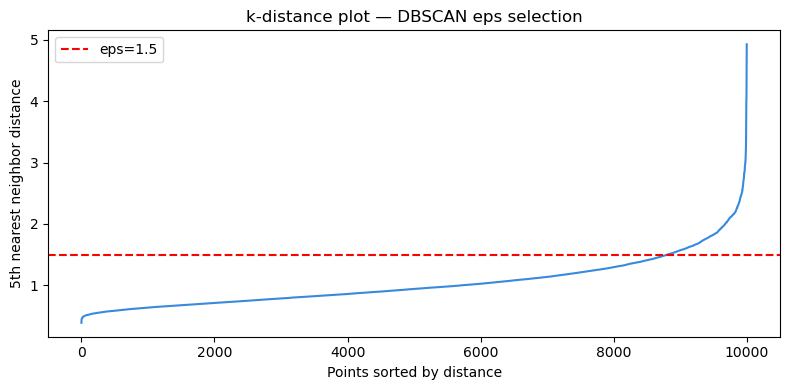

DBSCAN                 auto       0.0989     0.8788         24.7 eps=1.0 k=6 noise=40.2% sample
DBSCAN                 auto       0.6206     0.3831        117.9 eps=1.5 k=2 noise=10.0% sample
DBSCAN eps=2.0: k=1 — no valid clusters
OPTICS: k=1 — no valid clusters

Estimating bandwidth for Mean Shift (may take ~1 min)...
MeanShift              auto       0.3459     1.3690        673.2 k=5 sample n=10000


In [20]:
# ── Density-based — sample only ───────────────────────────────────
# HDBSCAN
hdb_s = HDBSCAN(min_cluster_size=100, min_samples=10,
                cluster_selection_method='eom')
labels_hdb_s = hdb_s.fit_predict(X_sample)
mask_s   = labels_hdb_s != -1
n_hdb_s  = len(set(labels_hdb_s[mask_s]))
noise_s  = (labels_hdb_s == -1).mean() * 100
if n_hdb_s > 1:
    sil = silhouette_score(X_sample[mask_s], labels_hdb_s[mask_s],
                           random_state=42)
    db  = davies_bouldin_score(X_sample[mask_s], labels_hdb_s[mask_s])
    ch  = calinski_harabasz_score(X_sample[mask_s], labels_hdb_s[mask_s])
    results['HDBSCAN_sample'] = {'labels': labels_hdb_s, 'silhouette': sil,
                                  'davies_bouldin': db, 'calinski': ch}
    print(f"{'HDBSCAN':<22} {'auto':>3} {sil:>12.4f} {db:>10.4f} {ch:>12.1f} "
          f"k={n_hdb_s} noise={noise_s:.1f}% sample")

# DBSCAN — k-distance plot first
from sklearn.neighbors import NearestNeighbors
nn = NearestNeighbors(n_neighbors=5).fit(X_sample)
dist, _ = nn.kneighbors(X_sample)
dist_sorted = np.sort(dist[:, -1])

plt.figure(figsize=(8, 4))
plt.plot(dist_sorted, color='#378ADD')
plt.title('k-distance plot — DBSCAN eps selection')
plt.xlabel('Points sorted by distance')
plt.ylabel('5th nearest neighbor distance')
plt.axhline(y=1.5, color='red', linestyle='--', label='eps=1.5')
plt.legend(); plt.tight_layout()
plt.savefig('dbscan_eps_2000.png', dpi=150, bbox_inches='tight')
plt.show()

for eps in [1.0, 1.5, 2.0]:
    db_model  = DBSCAN(eps=eps, min_samples=10)
    labels_db = db_model.fit_predict(X_sample)
    n_db      = len(set(labels_db)) - (1 if -1 in labels_db else 0)
    noise_db  = (labels_db == -1).mean() * 100
    if n_db > 1:
        mask_db = labels_db != -1
        sil = silhouette_score(X_sample[mask_db], labels_db[mask_db],
                               random_state=42)
        db  = davies_bouldin_score(X_sample[mask_db], labels_db[mask_db])
        ch  = calinski_harabasz_score(X_sample[mask_db], labels_db[mask_db])
        results[f"DBSCAN_eps{eps}"] = {'labels': labels_db, 'silhouette': sil,
                                        'davies_bouldin': db, 'calinski': ch}
        print(f"{'DBSCAN':<22} {'auto':>3} {sil:>12.4f} {db:>10.4f} {ch:>12.1f} "
              f"eps={eps} k={n_db} noise={noise_db:.1f}% sample")
    else:
        print(f"DBSCAN eps={eps}: k={n_db} — no valid clusters")

# OPTICS
from sklearn.cluster import OPTICS
opt = OPTICS(min_samples=10, xi=0.05, min_cluster_size=0.02)
labels_opt = opt.fit_predict(X_sample)
mask_opt   = labels_opt != -1
n_opt      = len(set(labels_opt[mask_opt]))
noise_opt  = (labels_opt == -1).mean() * 100
if n_opt > 1:
    sil = silhouette_score(X_sample[mask_opt], labels_opt[mask_opt],
                           random_state=42)
    db  = davies_bouldin_score(X_sample[mask_opt], labels_opt[mask_opt])
    ch  = calinski_harabasz_score(X_sample[mask_opt], labels_opt[mask_opt])
    results['OPTICS'] = {'labels': labels_opt, 'silhouette': sil,
                          'davies_bouldin': db, 'calinski': ch}
    print(f"{'OPTICS':<22} {'auto':>3} {sil:>12.4f} {db:>10.4f} {ch:>12.1f} "
          f"k={n_opt} noise={noise_opt:.1f}% sample")
else:
    print(f"OPTICS: k={n_opt} — no valid clusters")

# Mean Shift
from sklearn.cluster import MeanShift, estimate_bandwidth
print("\nEstimating bandwidth for Mean Shift (may take ~1 min)...")
bandwidth = estimate_bandwidth(X_sample, quantile=0.2, random_state=42)
ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
labels_ms = ms.fit_predict(X_sample)
n_ms = len(set(labels_ms))
sil = silhouette_score(X_sample, labels_ms, random_state=42)
db  = davies_bouldin_score(X_sample, labels_ms)
ch  = calinski_harabasz_score(X_sample, labels_ms)
results['MeanShift'] = {'labels': labels_ms, 'silhouette': sil,
                         'davies_bouldin': db, 'calinski': ch}
print(f"{'MeanShift':<22} {'auto':>3} {sil:>12.4f} {db:>10.4f} {ch:>12.1f} "
      f"k={n_ms} sample n={SAMPLE_SIZE}")

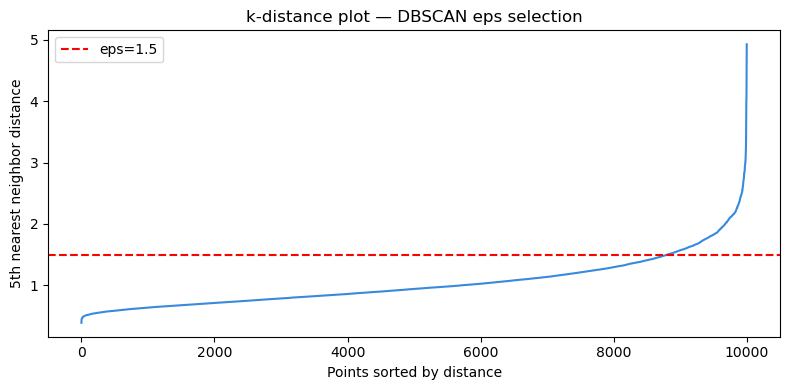

DBSCAN                 auto       0.0989     0.8788         24.7 eps=1.0 k=6 noise=40.2% sample
DBSCAN                 auto       0.6206     0.3831        117.9 eps=1.5 k=2 noise=10.0% sample
DBSCAN eps=2.0: k=1 — no valid clusters

Estimating bandwidth for Mean Shift (may take ~1 min)...
MeanShift              auto       0.3459     1.3690        673.2 k=5 sample n=10000


In [21]:
# ── Density-based — sample only ───────────────────────────────────
# HDBSCAN
hdb_s = HDBSCAN(min_cluster_size=100, min_samples=10,
                cluster_selection_method='eom')
labels_hdb_s = hdb_s.fit_predict(X_sample)
mask_s   = labels_hdb_s != -1
n_hdb_s  = len(set(labels_hdb_s[mask_s]))
noise_s  = (labels_hdb_s == -1).mean() * 100
if n_hdb_s > 1:
    sil = silhouette_score(X_sample[mask_s], labels_hdb_s[mask_s],
                           random_state=42)
    db  = davies_bouldin_score(X_sample[mask_s], labels_hdb_s[mask_s])
    ch  = calinski_harabasz_score(X_sample[mask_s], labels_hdb_s[mask_s])
    results['HDBSCAN_sample'] = {'labels': labels_hdb_s, 'silhouette': sil,
                                  'davies_bouldin': db, 'calinski': ch}
    print(f"{'HDBSCAN':<22} {'auto':>3} {sil:>12.4f} {db:>10.4f} {ch:>12.1f} "
          f"k={n_hdb_s} noise={noise_s:.1f}% sample")

# DBSCAN — k-distance plot first
from sklearn.neighbors import NearestNeighbors
nn = NearestNeighbors(n_neighbors=5).fit(X_sample)
dist, _ = nn.kneighbors(X_sample)
dist_sorted = np.sort(dist[:, -1])

plt.figure(figsize=(8, 4))
plt.plot(dist_sorted, color='#378ADD')
plt.title('k-distance plot — DBSCAN eps selection')
plt.xlabel('Points sorted by distance')
plt.ylabel('5th nearest neighbor distance')
plt.axhline(y=1.5, color='red', linestyle='--', label='eps=1.5')
plt.legend(); plt.tight_layout()
plt.savefig('dbscan_eps_2000.png', dpi=150, bbox_inches='tight')
plt.show()

for eps in [1.0, 1.5, 2.0]:
    db_model  = DBSCAN(eps=eps, min_samples=10)
    labels_db = db_model.fit_predict(X_sample)
    n_db      = len(set(labels_db)) - (1 if -1 in labels_db else 0)
    noise_db  = (labels_db == -1).mean() * 100
    if n_db > 1:
        mask_db = labels_db != -1
        sil = silhouette_score(X_sample[mask_db], labels_db[mask_db],
                               random_state=42)
        db  = davies_bouldin_score(X_sample[mask_db], labels_db[mask_db])
        ch  = calinski_harabasz_score(X_sample[mask_db], labels_db[mask_db])
        results[f"DBSCAN_eps{eps}"] = {'labels': labels_db, 'silhouette': sil,
                                        'davies_bouldin': db, 'calinski': ch}
        print(f"{'DBSCAN':<22} {'auto':>3} {sil:>12.4f} {db:>10.4f} {ch:>12.1f} "
              f"eps={eps} k={n_db} noise={noise_db:.1f}% sample")
    else:
        print(f"DBSCAN eps={eps}: k={n_db} — no valid clusters")

# Mean Shift
from sklearn.cluster import MeanShift, estimate_bandwidth
print("\nEstimating bandwidth for Mean Shift (may take ~1 min)...")
bandwidth = estimate_bandwidth(X_sample, quantile=0.2, random_state=42)
ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
labels_ms = ms.fit_predict(X_sample)
n_ms = len(set(labels_ms))
sil = silhouette_score(X_sample, labels_ms, random_state=42)
db  = davies_bouldin_score(X_sample, labels_ms)
ch  = calinski_harabasz_score(X_sample, labels_ms)
results['MeanShift'] = {'labels': labels_ms, 'silhouette': sil,
                         'davies_bouldin': db, 'calinski': ch}
print(f"{'MeanShift':<22} {'auto':>3} {sil:>12.4f} {db:>10.4f} {ch:>12.1f} "
      f"k={n_ms} sample n={SAMPLE_SIZE}")

### 3.2.4 Graph Spectral

In [19]:
# ── Graph / Spectral — sample only ────────────────────────────────
for k in N_CLUSTERS_LIST:
    spec = SpectralClustering(n_clusters=k, affinity='nearest_neighbors',
                              n_neighbors=10, random_state=42, n_jobs=-1)
    labels_spec = spec.fit_predict(X_sample)
    sil = silhouette_score(X_sample, labels_spec, random_state=42)
    db  = davies_bouldin_score(X_sample, labels_spec)
    ch  = calinski_harabasz_score(X_sample, labels_spec)
    results[f"Spectral_k{k}"] = {'labels': labels_spec, 'silhouette': sil,
                                   'davies_bouldin': db, 'calinski': ch}
    print(f"{'Spectral':<22} {k:>3} {sil:>12.4f} {db:>10.4f} {ch:>12.1f} "
          f"sample n={SAMPLE_SIZE}")

Spectral                 2       0.2259     1.6969       2918.5 sample n=10000
Spectral                 3       0.2057     1.4498       2651.5 sample n=10000
Spectral                 4       0.2000     1.3771       2407.1 sample n=10000


In [39]:
# ── Spectral — n=50k ──────────────────────────────────────────────
print("Running Spectral Clustering on n=50k (may take a while)...")

SAMPLE_SIZE_SPECTRAL = 50000
np.random.seed(42)
idx_spectral = np.random.choice(len(X_scaled), SAMPLE_SIZE_SPECTRAL, replace=False)
X_spectral   = X_scaled.iloc[idx_spectral]

for k in N_CLUSTERS_LIST:
    try:
        spec = SpectralClustering(n_clusters=k, affinity='nearest_neighbors',
                                  n_neighbors=10, random_state=42, n_jobs=-1)
        labels_spec = spec.fit_predict(X_spectral)
        sil = silhouette_score(X_spectral, labels_spec,
                               sample_size=10000, random_state=42)
        db  = davies_bouldin_score(X_spectral, labels_spec)
        ch  = calinski_harabasz_score(X_spectral, labels_spec)
        results[f"Spectral_50k_k{k}"] = {'labels': labels_spec,
                                          'silhouette': sil,
                                          'davies_bouldin': db,
                                          'calinski': ch}
        print(f"{'Spectral':<22} {k:>3} {sil:>12.4f} {db:>10.4f} {ch:>12.1f} "
              f"sample n=50k")
    except MemoryError:
        print(f"Spectral k={k}: MemoryError — insufficient RAM for n=50k")
        break

Running Spectral Clustering on n=50k (may take a while)...
Spectral                 2       0.5081     0.4983         71.3 sample n=50k
Spectral                 3       0.2338     1.3100       7479.7 sample n=50k
Spectral                 4       0.2162     1.2115       8886.6 sample n=50k


### 3.2.5 Neural

In [41]:
# UMAP + HDBSCAN
print("\nRunning UMAP + HDBSCAN...")
reducer = umap.UMAP(n_components=10, n_neighbors=15, min_dist=0.1,
                    metric='euclidean', random_state=42)
X_umap = reducer.fit_transform(X_sample)

hdb_umap    = HDBSCAN(min_cluster_size=100, min_samples=10,
                      cluster_selection_method='eom')
labels_umap = hdb_umap.fit_predict(X_umap)
mask_umap   = labels_umap != -1
n_umap      = len(set(labels_umap[mask_umap]))
noise_umap  = (labels_umap == -1).mean() * 100

if n_umap > 1:
    sil = silhouette_score(X_umap[mask_umap], labels_umap[mask_umap],
                           random_state=42)
    db  = davies_bouldin_score(X_umap[mask_umap], labels_umap[mask_umap])
    ch  = calinski_harabasz_score(X_umap[mask_umap], labels_umap[mask_umap])
    results['UMAP+HDBSCAN'] = {'labels': labels_umap, 'silhouette': sil,
                                'davies_bouldin': db, 'calinski': ch}
    print(f"{'UMAP+HDBSCAN':<22} {'auto':>3} {sil:>12.4f} {db:>10.4f} "
          f"{ch:>12.1f} k={n_umap} noise={noise_umap:.1f}% sample")


Running UMAP + HDBSCAN...
UMAP+HDBSCAN           auto       0.3171     0.8165       2444.1 k=15 noise=59.1% sample


In [43]:
# UMAP + HDBSCAN
print("\nRunning UMAP + HDBSCAN...")
reducer = umap.UMAP(n_components=10, n_neighbors=15, min_dist=0.1,
                    metric='euclidean', random_state=42)
X_umap = reducer.fit_transform(X_sample)

hdb_umap    = HDBSCAN(min_cluster_size=100, min_samples=10,
                      cluster_selection_method='eom')
labels_umap = hdb_umap.fit_predict(X_umap)
mask_umap   = labels_umap != -1
n_umap      = len(set(labels_umap[mask_umap]))
noise_umap  = (labels_umap == -1).mean() * 100

if n_umap > 1:
    sil = silhouette_score(X_umap[mask_umap], labels_umap[mask_umap],
                           random_state=42)
    db  = davies_bouldin_score(X_umap[mask_umap], labels_umap[mask_umap])
    ch  = calinski_harabasz_score(X_umap[mask_umap], labels_umap[mask_umap])
    results['UMAP+HDBSCAN'] = {'labels': labels_umap, 'silhouette': sil,
                                'davies_bouldin': db, 'calinski': ch}
    print(f"{'UMAP+HDBSCAN':<22} {'auto':>3} {sil:>12.4f} {db:>10.4f} "
          f"{ch:>12.1f} k={n_umap} noise={noise_umap:.1f}% sample")


Running UMAP + HDBSCAN...
UMAP+HDBSCAN           auto       0.3171     0.8165       2444.1 k=15 noise=59.1% sample


In [44]:
# UMAP + HDBSCAN
print("\nRunning UMAP + HDBSCAN...")
SAMPLE_SIZE_UMAP = 50000
np.random.seed(42)
idx_umap   = np.random.choice(len(X_scaled), SAMPLE_SIZE_UMAP, replace=False)
X_umap_in  = X_scaled.iloc[idx_umap]

reducer = umap.UMAP(n_components=10, n_neighbors=15, min_dist=0.1,
                    metric='euclidean', random_state=42)
X_umap = reducer.fit_transform(X_umap_in)

hdb_umap    = HDBSCAN(min_cluster_size=100, min_samples=10,
                      cluster_selection_method='eom')
labels_umap = hdb_umap.fit_predict(X_umap)
mask_umap   = labels_umap != -1
n_umap      = len(set(labels_umap[mask_umap]))
noise_umap  = (labels_umap == -1).mean() * 100

if n_umap > 1:
    sil = silhouette_score(X_umap[mask_umap], labels_umap[mask_umap],
                           random_state=42)
    db  = davies_bouldin_score(X_umap[mask_umap], labels_umap[mask_umap])
    ch  = calinski_harabasz_score(X_umap[mask_umap], labels_umap[mask_umap])
    results['UMAP+HDBSCAN'] = {'labels': labels_umap, 'silhouette': sil,
                                'davies_bouldin': db, 'calinski': ch}
    print(f"{'UMAP+HDBSCAN':<22} {'auto':>3} {sil:>12.4f} {db:>10.4f} "
          f"{ch:>12.1f} k={n_umap} noise={noise_umap:.1f}% n={SAMPLE_SIZE_UMAP}")



Running UMAP + HDBSCAN...
UMAP+HDBSCAN           auto       0.2873     0.9075       6431.2 k=35 noise=68.9% n=50000


In [45]:
# UMAP + HDBSCAN
print("\nRunning UMAP + HDBSCAN...")
SAMPLE_SIZE_UMAP = 100000
np.random.seed(42)
idx_umap   = np.random.choice(len(X_scaled), SAMPLE_SIZE_UMAP, replace=False)
X_umap_in  = X_scaled.iloc[idx_umap]

reducer = umap.UMAP(n_components=10, n_neighbors=15, min_dist=0.1,
                    metric='euclidean', random_state=42)
X_umap = reducer.fit_transform(X_umap_in)

hdb_umap    = HDBSCAN(min_cluster_size=100, min_samples=10,
                      cluster_selection_method='eom')
labels_umap = hdb_umap.fit_predict(X_umap)
mask_umap   = labels_umap != -1
n_umap      = len(set(labels_umap[mask_umap]))
noise_umap  = (labels_umap == -1).mean() * 100

if n_umap > 1:
    sil = silhouette_score(X_umap[mask_umap], labels_umap[mask_umap],
                           random_state=42)
    db  = davies_bouldin_score(X_umap[mask_umap], labels_umap[mask_umap])
    ch  = calinski_harabasz_score(X_umap[mask_umap], labels_umap[mask_umap])
    results['UMAP+HDBSCAN'] = {'labels': labels_umap, 'silhouette': sil,
                                'davies_bouldin': db, 'calinski': ch}
    print(f"{'UMAP+HDBSCAN':<22} {'auto':>3} {sil:>12.4f} {db:>10.4f} "
          f"{ch:>12.1f} k={n_umap} noise={noise_umap:.1f}% n={SAMPLE_SIZE_UMAP}")



Running UMAP + HDBSCAN...
UMAP+HDBSCAN           auto       0.0464     0.8951        123.9 k=2 noise=0.3% n=100000


### 3.2.6 Bigger Sample for Promising Algorithms

In [22]:
# Definir X_large (30k)
SAMPLE_SIZE_LARGE = 30000
np.random.seed(42)
idx_large = np.random.choice(len(X_scaled), SAMPLE_SIZE_LARGE, replace=False)
X_large   = X_scaled.iloc[idx_large]
# DBSCAN eps=1.5 con n=30k
db_model  = DBSCAN(eps=1.5, min_samples=10)
labels_db = db_model.fit_predict(X_large)
mask_db   = labels_db != -1
n_db      = len(set(labels_db[mask_db]))
noise_db  = (labels_db == -1).mean() * 100
if n_db > 1:
    sil = silhouette_score(X_large[mask_db], labels_db[mask_db],
                           sample_size=10000, random_state=42)
    db  = davies_bouldin_score(X_large[mask_db], labels_db[mask_db])
    ch  = calinski_harabasz_score(X_large[mask_db], labels_db[mask_db])
    print(f"DBSCAN eps=1.5 (n=30k): k={n_db} sil={sil:.4f} "
          f"db={db:.4f} noise={noise_db:.1f}%")

# MeanShift con n=30k
bandwidth = estimate_bandwidth(X_large, quantile=0.2, random_state=42)
ms        = MeanShift(bandwidth=bandwidth, bin_seeding=True)
labels_ms = ms.fit_predict(X_large)
n_ms      = len(set(labels_ms))
sil       = silhouette_score(X_large, labels_ms,
                             sample_size=10000, random_state=42)
db        = davies_bouldin_score(X_large, labels_ms)
ch        = calinski_harabasz_score(X_large, labels_ms)
print(f"MeanShift (n=30k): k={n_ms} sil={sil:.4f} db={db:.4f} ch={ch:.1f}")

DBSCAN eps=1.5 (n=30k): k=3 sil=0.4363 db=0.5830 noise=5.0%
MeanShift (n=30k): k=6 sil=0.3302 db=1.3202 ch=1576.6


In [23]:
import numpy as np
from sklearn.utils import check_random_state

# 1. Definimos un tamaño inicial mayor para asegurar 100k limpios tras quitar el ruido
SAMPLE_SIZE_LARGE = 120000  

np.random.seed(42)
idx_large = np.random.choice(len(X_scaled), SAMPLE_SIZE_LARGE, replace=False)
X_large   = X_scaled.iloc[idx_large].reset_index(drop=True) # reset_index crucial aquí

# DBSCAN eps=1.5
db_model  = DBSCAN(eps=1.5, min_samples=10)
labels_db = db_model.fit_predict(X_large)

mask_db   = labels_db != -1
filtered_labels = labels_db[mask_db]
filtered_X      = X_large[mask_db]

n_db     = len(np.unique(filtered_labels))
noise_db = (labels_db == -1).mean() * 100

print(f"Puntos totales muestreados: {SAMPLE_SIZE_LARGE}")
print(f"Puntos limpios (sin ruido) detectados por DBSCAN: {len(filtered_X)}")

if n_db > 1:
    TARGET_SAMPLES = 100000
    
    # 2. Extraemos exactamente 100,000 puntos limpios de forma controlada
    if len(filtered_X) >= TARGET_SAMPLES:
        rng = check_random_state(42)
        idx_sample = rng.choice(len(filtered_X), size=TARGET_SAMPLES, replace=False)
        X_sample = filtered_X.iloc[idx_sample]
        labels_sample = filtered_labels[idx_sample]
    else:
        # Si por exceso de ruido quedaron menos de 100k, usamos todos los disponibles
        X_sample, labels_sample = filtered_X, filtered_labels
        print(f"Aviso: Quedaron menos de 100k puntos tras filtrar el ruido. Usando {len(X_sample)}")

    # 3. Validamos que la muestra final de 100k mantenga la diversidad de clústeres
    if len(np.unique(labels_sample)) > 1:
        # Al pasarle ya el dataset recortado a 100k, no necesitas el parámetro 'sample_size' interno
        sil = silhouette_score(X_sample, labels_sample) 
        db  = davies_bouldin_score(X_sample, labels_sample)
        ch  = calinski_harabasz_score(X_sample, labels_sample)
        
        print(f"\n--- RESULTADOS DBSCAN ---")
        print(f"Evaluado con n_muestras = {len(X_sample)}")
        print(f"Clústeres válidos (k): {n_db}")
        print(f"Silhouette Score: {sil:.4f}")
        print(f"Davies-Bouldin: {db:.4f}")
        print(f"Calinski-Harabasz: {ch:.1f}")
        print(f"Porcentaje de ruido: {noise_db:.1f}%")
    else:
        print("Error: El submuestreo final dejó un solo clúster. No se puede calcular Silhouette.")
else:
    print(f"DBSCAN eps=1.5: k={n_db} — No hay suficientes clústeres válidos.")

Puntos totales muestreados: 120000
Puntos limpios (sin ruido) detectados por DBSCAN: 118131

--- RESULTADOS DBSCAN ---
Evaluado con n_muestras = 100000
Clústeres válidos (k): 4
Silhouette Score: 0.3305
Davies-Bouldin: 0.5718
Calinski-Harabasz: 64.4
Porcentaje de ruido: 1.6%


In [ ]:
import numpy as np
from sklearn.cluster import DBSCAN, MeanShift, estimate_bandwidth
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.utils import check_random_state

# =====================================================================
# 1. PREPARACIÓN DE LA MUESTRA GRANDE (Para buscar ~100k limpios)
# =====================================================================
SAMPLE_SIZE_LARGE = 120000  
TARGET_SAMPLES = 100000

np.random.seed(42)
idx_large = np.random.choice(len(X_scaled), SAMPLE_SIZE_LARGE, replace=False)
X_large   = X_scaled.iloc[idx_large].reset_index(drop=True)

print(f"--- CONFIGURACIÓN INICIAL ---")
print(f"Tamaño de muestra base: {SAMPLE_SIZE_LARGE} registros.\n")


# =====================================================================
# 2. SECCIÓN: DBSCAN
# =====================================================================
print("Ejecutando DBSCAN...")
db_model  = DBSCAN(eps=1.5, min_samples=10)
labels_db = db_model.fit_predict(X_large)

mask_db   = labels_db != -1
filtered_labels_db = labels_db[mask_db]
filtered_X_db      = X_large[mask_db]

n_db     = len(np.unique(filtered_labels_db))
noise_db = (labels_db == -1).mean() * 100

if n_db > 1:
    # Ajustamos estrictamente a 100k (o el máximo disponible si hay demasiado ruido)
    if len(filtered_X_db) >= TARGET_SAMPLES:
        rng = check_random_state(42)
        idx_sample = rng.choice(len(filtered_X_db), size=TARGET_SAMPLES, replace=False)
        X_sample_db = filtered_X_db.iloc[idx_sample]
        labels_sample_db = filtered_labels_db[idx_sample]
    else:
        X_sample_db, labels_sample_db = filtered_X_db, filtered_labels_db
        print(f" Avisos DBSCAN: Quedaron menos de 100k puntos sin ruido. Usando {len(X_sample_db)}")

    if len(np.unique(labels_sample_db)) > 1:
        sil_db = silhouette_score(X_sample_db, labels_sample_db)
        db_db  = davies_bouldin_score(X_sample_db, labels_sample_db)
        ch_db  = calinski_harabasz_score(X_sample_db, labels_sample_db)
        print(f" DBSCAN OK -> k={n_db} | sil={sil_db:.4f} | db={db_db:.4f} | ch={ch_db:.1f} | noise={noise_db:.1f}%")
    else:
        print(" DBSCAN Error: El submuestreo destruyó la variedad de clústeres.")
else:
    print(f" DBSCAN Error: k={n_db} — No hay suficientes clústeres válidos (solo ruido o 1 solo clúster).")

print("-" * 60)


# =====================================================================
# 3. SECCIÓN: MEANSHIFT
# =====================================================================
print("Ejecutando MeanShift (esto puede tardar bastante)...")

# Opcional: Si notas que MeanShift te congela la PC, descomenta la línea de abajo 
# para recortar X_large_ms a 30000 muestras solo para este algoritmo.
# X_large_ms = X_large.sample(n=30000, random_state=42).reset_index(drop=True)
X_large_ms = X_large 

# Estimamos ancho de banda con una fracción de los datos para no morir en el intento
bandwidth = estimate_bandwidth(X_large_ms, quantile=0.2, random_state=42, n_samples=10000)

ms        = MeanShift(bandwidth=bandwidth, bin_seeding=True)
labels_ms = ms.fit_predict(X_large_ms)
n_ms      = len(np.unique(labels_ms))

if n_ms > 1:
    # MeanShift no genera "ruido (-1)", así que recortamos directamente a 100k si es necesario
    if len(X_large_ms) >= TARGET_SAMPLES:
        rng = check_random_state(42)
        idx_sample_ms = rng.choice(len(X_large_ms), size=TARGET_SAMPLES, replace=False)
        X_sample_ms = X_large_ms.iloc[idx_sample_ms]
        labels_sample_ms = labels_ms[idx_sample_ms]
    else:
        X_sample_ms, labels_sample_ms = X_large_ms, labels_ms

    if len(np.unique(labels_sample_ms)) > 1:
        sil_ms = silhouette_score(X_sample_ms, labels_sample_ms)
        db_ms  = davies_bouldin_score(X_sample_ms, labels_sample_ms)
        ch_ms  = calinski_harabasz_score(X_sample_ms, labels_sample_ms)
        print(f" MeanShift OK -> k={n_ms} | sil={sil_ms:.4f} | db={db_ms:.4f} | ch={ch_ms:.1f}")
    else:
        print(" MeanShift Error: El submuestreo de 100k dejó un solo clúster.")
else:
    print(f" MeanShift Error: k={n_ms} — El algoritmo solo encontró un clúster masivo.")

DBSCAN eps=1.5 (n=100k): k=5 sil=0.4558 db=0.5040 noise=2.3%
MeanShift (n=50k): k=5 sil=0.3529 db=1.4154 ch=7717.8


In [52]:
# Definir X_large (30k)
SAMPLE_SIZE_LARGE = 100000
np.random.seed(42)
idx_large = np.random.choice(len(X_scaled), SAMPLE_SIZE_LARGE, replace=False)
X_large   = X_scaled.iloc[idx_large]
# MeanShift and DBSCAN — full dataset
print("Running MeanShift on full dataset...")

# ── MeanShift ──────────────────────────────────────────────────────
bandwidth = estimate_bandwidth(X_scaled, quantile=0.2,
                               random_state=42, n_samples=10000)
print(f"Bandwidth estimated: {bandwidth:.4f}")

ms_full        = MeanShift(bandwidth=bandwidth, bin_seeding=True, n_jobs=-1)
labels_ms_full = ms_full.fit_predict(X_scaled)
n_ms_full      = len(set(labels_ms_full))

sil_ms = silhouette_score(X_scaled, labels_ms_full,
                          sample_size=10000, random_state=42)
db_ms  = davies_bouldin_score(X_scaled, labels_ms_full)
ch_ms  = calinski_harabasz_score(X_scaled, labels_ms_full)

print(f"\nMeanShift (full 177k): k={n_ms_full} sil={sil_ms:.4f} "
      f"db={db_ms:.4f} ch={ch_ms:.1f}")
print(f"Cluster sizes:")
print(pd.Series(labels_ms_full).value_counts().sort_index())

# ── DBSCAN ────────────────────────────────────────────────────────
print("\nRunning DBSCAN on full dataset...")

db_model       = DBSCAN(eps=1.5, min_samples=10, n_jobs=-1,
                        algorithm='ball_tree')
labels_db_full = db_model.fit_predict(X_scaled)
mask_db_full   = labels_db_full != -1
n_db_full      = len(set(labels_db_full[mask_db_full]))
noise_db_full  = (labels_db_full == -1).mean() * 100

if n_db_full > 1:
    sil_db = silhouette_score(X_scaled[mask_db_full],
                              labels_db_full[mask_db_full],
                              sample_size=10000, random_state=42)
    db_db  = davies_bouldin_score(X_scaled[mask_db_full],
                                  labels_db_full[mask_db_full])
    ch_db  = calinski_harabasz_score(X_scaled[mask_db_full],
                                     labels_db_full[mask_db_full])
    print(f"\nDBSCAN eps=1.5 (full 177k): k={n_db_full} sil={sil_db:.4f} "
          f"db={db_db:.4f} noise={noise_db_full:.1f}%")
else:
    print(f"\nDBSCAN eps=1.5 (full 177k): k={n_db_full} — no valid clusters")

print(f"Cluster sizes:")
print(pd.Series(labels_db_full).value_counts().sort_index())

Running MeanShift on full dataset...
Bandwidth estimated: 3.1241

MeanShift (full 177k): k=4 sil=0.3731 db=1.2328 ch=27276.0
Cluster sizes:
0    340169
1      3456
2      6071
3      6966
Name: count, dtype: int64

Running DBSCAN on full dataset...

DBSCAN eps=1.5 (full 177k): k=7 sil=0.4432 db=0.6077 noise=0.6%
Cluster sizes:
-1      2061
 0    354421
 1         7
 2        33
 3        52
 4        66
 5        12
 6        10
Name: count, dtype: int64


In [36]:
# Definir X_large (30k)
SAMPLE_SIZE_LARGE = 356662 
np.random.seed(42)
idx_large = np.random.choice(len(X_scaled), SAMPLE_SIZE_LARGE, replace=False)
X_large   = X_scaled.iloc[idx_large]
# MeanShift and DBSCAN — full dataset
print("Running MeanShift on full dataset...")

# ── MeanShift ──────────────────────────────────────────────────────
bandwidth = estimate_bandwidth(X_scaled, quantile=0.2,
                               random_state=42, n_samples=10000)
print(f"Bandwidth estimated: {bandwidth:.4f}")

ms_full        = MeanShift(bandwidth=bandwidth, bin_seeding=True, n_jobs=-1)
labels_ms_full = ms_full.fit_predict(X_scaled)
n_ms_full      = len(set(labels_ms_full))

sil_ms = silhouette_score(X_scaled, labels_ms_full,
                          sample_size=10000, random_state=42)
db_ms  = davies_bouldin_score(X_scaled, labels_ms_full)
ch_ms  = calinski_harabasz_score(X_scaled, labels_ms_full)

print(f"\nMeanShift (full 177k): k={n_ms_full} sil={sil_ms:.4f} "
      f"db={db_ms:.4f} ch={ch_ms:.1f}")
print(f"Cluster sizes:")
print(pd.Series(labels_ms_full).value_counts().sort_index())

Running MeanShift on full dataset...
Bandwidth estimated: 3.1241

MeanShift (full 177k): k=4 sil=0.3731 db=1.2328 ch=27276.0
Cluster sizes:
0    340169
1      3456
2      6071
3      6966
Name: count, dtype: int64


In [37]:
# ── Verificar si los clusters de MeanShift son reales ─────────────
df_check_ms = df_clean.copy()
df_check_ms['cluster_ms'] = labels_ms_full

print("=== MeanShift — cluster sizes ===")
print(pd.Series(labels_ms_full).value_counts().sort_index())

print("\n=== Equivalent diameter per cluster ===")
print(df_check_ms.groupby('cluster_ms')['equivalent_diameter'].describe().round(3))

print("\n=== Solidity per cluster ===")
print(df_check_ms.groupby('cluster_ms')['solidity'].describe().round(3))

print("\n=== Aspect ratio per cluster ===")
print(df_check_ms.groupby('cluster_ms')['aspect_ratio'].describe().round(3))

print("\n=== Roundness per cluster ===")
print(df_check_ms.groupby('cluster_ms')['roundness'].describe().round(3))

cols_show = ['equivalent_diameter', 'roundness', 'aspect_ratio',
             'solidity', 'feret_ratio', 'mean_intensity',
             'std_intensity', 'glcm_correlation', 'lbp_mean']

print("\n=== Median per cluster — all key variables ===")
print(df_check_ms.groupby('cluster_ms')[cols_show].median().round(3).T.to_string())

print("\n=== Std per cluster — all key variables ===")
print(df_check_ms.groupby('cluster_ms')[cols_show].std().round(3).T.to_string())

=== MeanShift — cluster sizes ===
0    340169
1      3456
2      6071
3      6966
Name: count, dtype: int64

=== Equivalent diameter per cluster ===
               count    mean    std    min     25%     50%     75%     max
cluster_ms                                                                
0           340169.0   6.010  2.236  3.909   4.370   5.293   6.864  16.926
1             3456.0  15.214  2.592  4.370  13.912  16.926  16.926  16.926
2             6071.0   6.588  2.820  3.909   4.652   5.754   7.569  16.926
3             6966.0   7.805  3.664  3.909   5.046   6.580   9.441  16.926

=== Solidity per cluster ===
               count   mean    std    min    25%    50%    75%    max
cluster_ms                                                           
0           340169.0  0.803  0.130  0.303  0.708  0.824  0.910  1.000
1             3456.0  0.589  0.130  0.302  0.492  0.579  0.677  0.964
2             6071.0  0.548  0.090  0.301  0.492  0.545  0.595  1.000
3             6966.0 

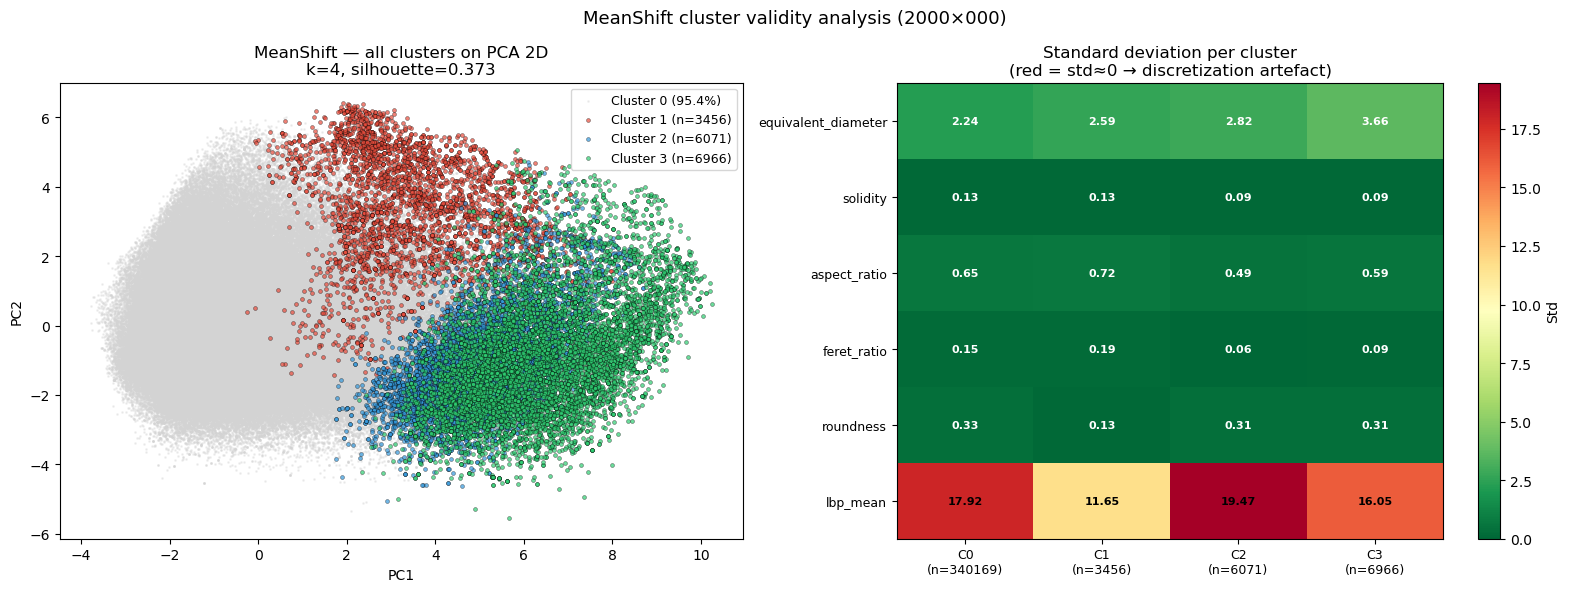

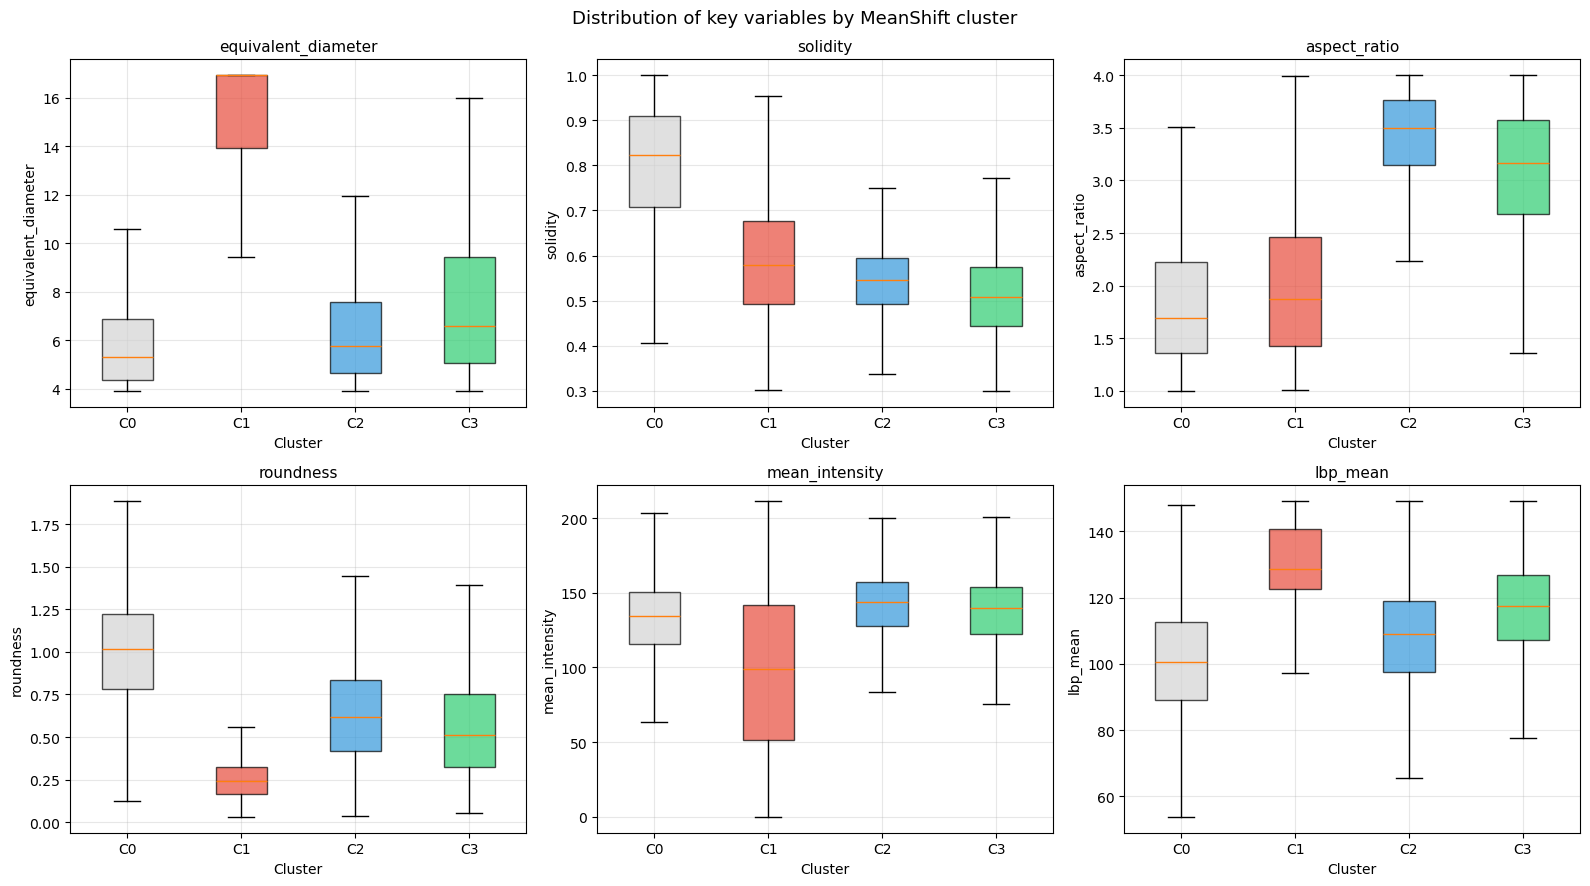

In [38]:
# ── Visualization — MeanShift cluster validity ────────────────────
pca_ms = PCA(n_components=2, random_state=42)
X_2d_ms = pca_ms.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Plot 1: PCA con todos los clusters de MeanShift ────────────────
cluster_ids_ms = sorted(set(labels_ms_full))
colors_ms      = ['lightgray', '#E74C3C', '#3498DB', '#2ECC71',
                  '#F39C12', '#9B59B6', '#1ABC9C']

for cl, color in zip(cluster_ids_ms, colors_ms):
    mask_cl = labels_ms_full == cl
    n = mask_cl.sum()
    pct = n / len(labels_ms_full) * 100
    if cl == 0:
        axes[0].scatter(X_2d_ms[mask_cl, 0], X_2d_ms[mask_cl, 1],
                        c=color, s=1, alpha=0.3,
                        label=f'Cluster {cl} ({pct:.1f}%)')
    else:
        axes[0].scatter(X_2d_ms[mask_cl, 0], X_2d_ms[mask_cl, 1],
                        c=color, s=8, alpha=0.7,
                        label=f'Cluster {cl} (n={n})',
                        edgecolors='black', linewidth=0.3)

axes[0].set_title(f'MeanShift — all clusters on PCA 2D\n'
                  f'k={n_ms_full}, silhouette={sil_ms:.3f}')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend(loc='best', fontsize=9)

# ── Plot 2: Heatmap std por cluster ────────────────────────────────
cols_check = ['equivalent_diameter', 'solidity', 'aspect_ratio',
              'feret_ratio', 'roundness', 'lbp_mean']

std_matrix_ms = np.zeros((len(cols_check), len(cluster_ids_ms)))

for j, cl in enumerate(cluster_ids_ms):
    mask_cl = labels_ms_full == cl
    for i, col in enumerate(cols_check):
        std_matrix_ms[i, j] = df_clean[col][mask_cl].std()

im = axes[1].imshow(std_matrix_ms, aspect='auto', cmap='RdYlGn_r',
                    vmin=0, vmax=std_matrix_ms.max())
axes[1].set_xticks(range(len(cluster_ids_ms)))
axes[1].set_xticklabels([f'C{c}\n(n={(labels_ms_full==c).sum()})'
                          for c in cluster_ids_ms], fontsize=9)
axes[1].set_yticks(range(len(cols_check)))
axes[1].set_yticklabels(cols_check, fontsize=9)
axes[1].set_title('Standard deviation per cluster\n'
                  '(red = std≈0 → discretization artefact)')

for i in range(len(cols_check)):
    for j in range(len(cluster_ids_ms)):
        val = std_matrix_ms[i, j]
        color = 'white' if val < 0.5 * std_matrix_ms.max() else 'black'
        axes[1].text(j, i, f'{val:.2f}', ha='center', va='center',
                     color=color, fontsize=8, fontweight='bold')

plt.colorbar(im, ax=axes[1], label='Std')
plt.suptitle('MeanShift cluster validity analysis (2000×000)', fontsize=13)
plt.tight_layout()
plt.savefig('meanshift_cluster_validity.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 3: Distribución de variables clave por cluster ───────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
cols_box = ['equivalent_diameter', 'solidity', 'aspect_ratio',
            'roundness', 'mean_intensity', 'lbp_mean']

for ax, col in zip(axes.flatten(), cols_box):
    data_by_cluster = [df_clean[col][labels_ms_full == c].values
                       for c in cluster_ids_ms]
    bp = ax.boxplot(data_by_cluster,
                    labels=[f'C{c}' for c in cluster_ids_ms],
                    patch_artist=True, showfliers=False)

    for patch, color in zip(bp['boxes'], colors_ms):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.set_title(col, fontsize=11)
    ax.set_xlabel('Cluster'); ax.set_ylabel(col)
    ax.grid(True, alpha=0.3)

plt.suptitle('Distribution of key variables by MeanShift cluster',
             fontsize=13)
plt.tight_layout()
plt.savefig('meanshift_cluster_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [40]:
# Definir X_large (30k)
SAMPLE_SIZE_LARGE = 356662
np.random.seed(42)
idx_large = np.random.choice(len(X_scaled), SAMPLE_SIZE_LARGE, replace=False)
X_large   = X_scaled.iloc[idx_large]
# MeanShift and DBSCAN — full dataset
print("Running MeanShift on full dataset...")


# ── DBSCAN ────────────────────────────────────────────────────────
print("\nRunning DBSCAN on full dataset...")

db_model       = DBSCAN(eps=1.5, min_samples=10, n_jobs=-1,
                        algorithm='ball_tree')
labels_db_full = db_model.fit_predict(X_scaled)
mask_db_full   = labels_db_full != -1
n_db_full      = len(set(labels_db_full[mask_db_full]))
noise_db_full  = (labels_db_full == -1).mean() * 100

if n_db_full > 1:
    sil_db = silhouette_score(X_scaled[mask_db_full],
                              labels_db_full[mask_db_full],
                              sample_size=10000, random_state=42)
    db_db  = davies_bouldin_score(X_scaled[mask_db_full],
                                  labels_db_full[mask_db_full])
    ch_db  = calinski_harabasz_score(X_scaled[mask_db_full],
                                     labels_db_full[mask_db_full])
    print(f"\nDBSCAN eps=1.5 (full 177k): k={n_db_full} sil={sil_db:.4f} "
          f"db={db_db:.4f} noise={noise_db_full:.1f}%")
else:
    print(f"\nDBSCAN eps=1.5 (full 177k): k={n_db_full} — no valid clusters")

print(f"Cluster sizes:")
print(pd.Series(labels_db_full).value_counts().sort_index())

Running MeanShift on full dataset...

Running DBSCAN on full dataset...

DBSCAN eps=1.5 (full 177k): k=7 sil=0.4432 db=0.6077 noise=0.6%
Cluster sizes:
-1      2061
 0    354421
 1         7
 2        33
 3        52
 4        66
 5        12
 6        10
Name: count, dtype: int64



  VALIDACIÓN DE CLUSTERS DBSCAN  —  7 clusters



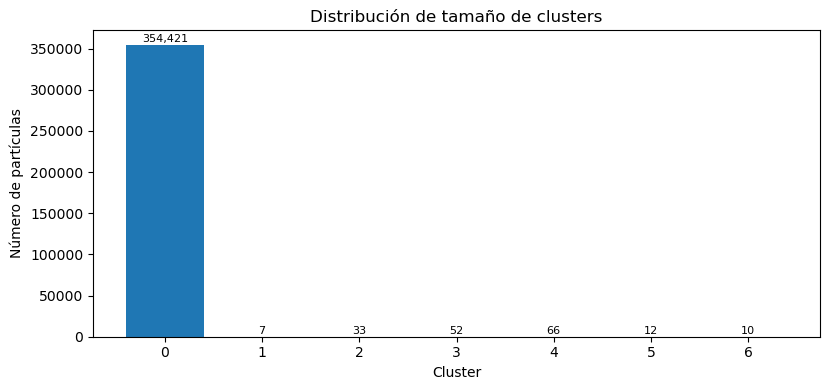

Medias por cluster (valores escalados):
cluster                  0      1      2      3      4      5      6
equivalent_diameter  0.323  4.439  4.276 -0.103  4.499  0.089 -0.410
roundness           -0.022 -1.618 -1.758 -0.151 -1.783 -1.045  0.505
aspect_ratio         0.207  1.323  0.190 -0.772 -0.478  0.849 -0.772
compactness          0.173  2.762  3.021  0.375  3.015  1.414 -0.412
solidity            -0.097 -1.392 -1.846  0.876 -1.004 -1.447  0.876
feret_ratio         -0.006 -0.818  0.032 -2.275  1.100 -0.476 -2.275
mean_intensity      -0.077 -0.770 -2.300  0.108 -3.809  0.766  0.120
std_intensity        0.408  2.218  2.269 -0.148 -0.340 -0.461  0.140
intensity_entropy   -0.330  0.038 -0.237 -0.367 -2.588 -2.588  0.252
glcm_energy          0.114 -1.265 -1.330 -1.357  2.934  3.447  0.968
glcm_correlation    -0.166  0.859  0.811  0.908  0.904  0.210 -0.013
lbp_mean             0.009  0.906  1.051 -2.582  1.988  1.814 -3.846
hu1                  0.242  2.477  2.562  2.876  0.884  2.259  

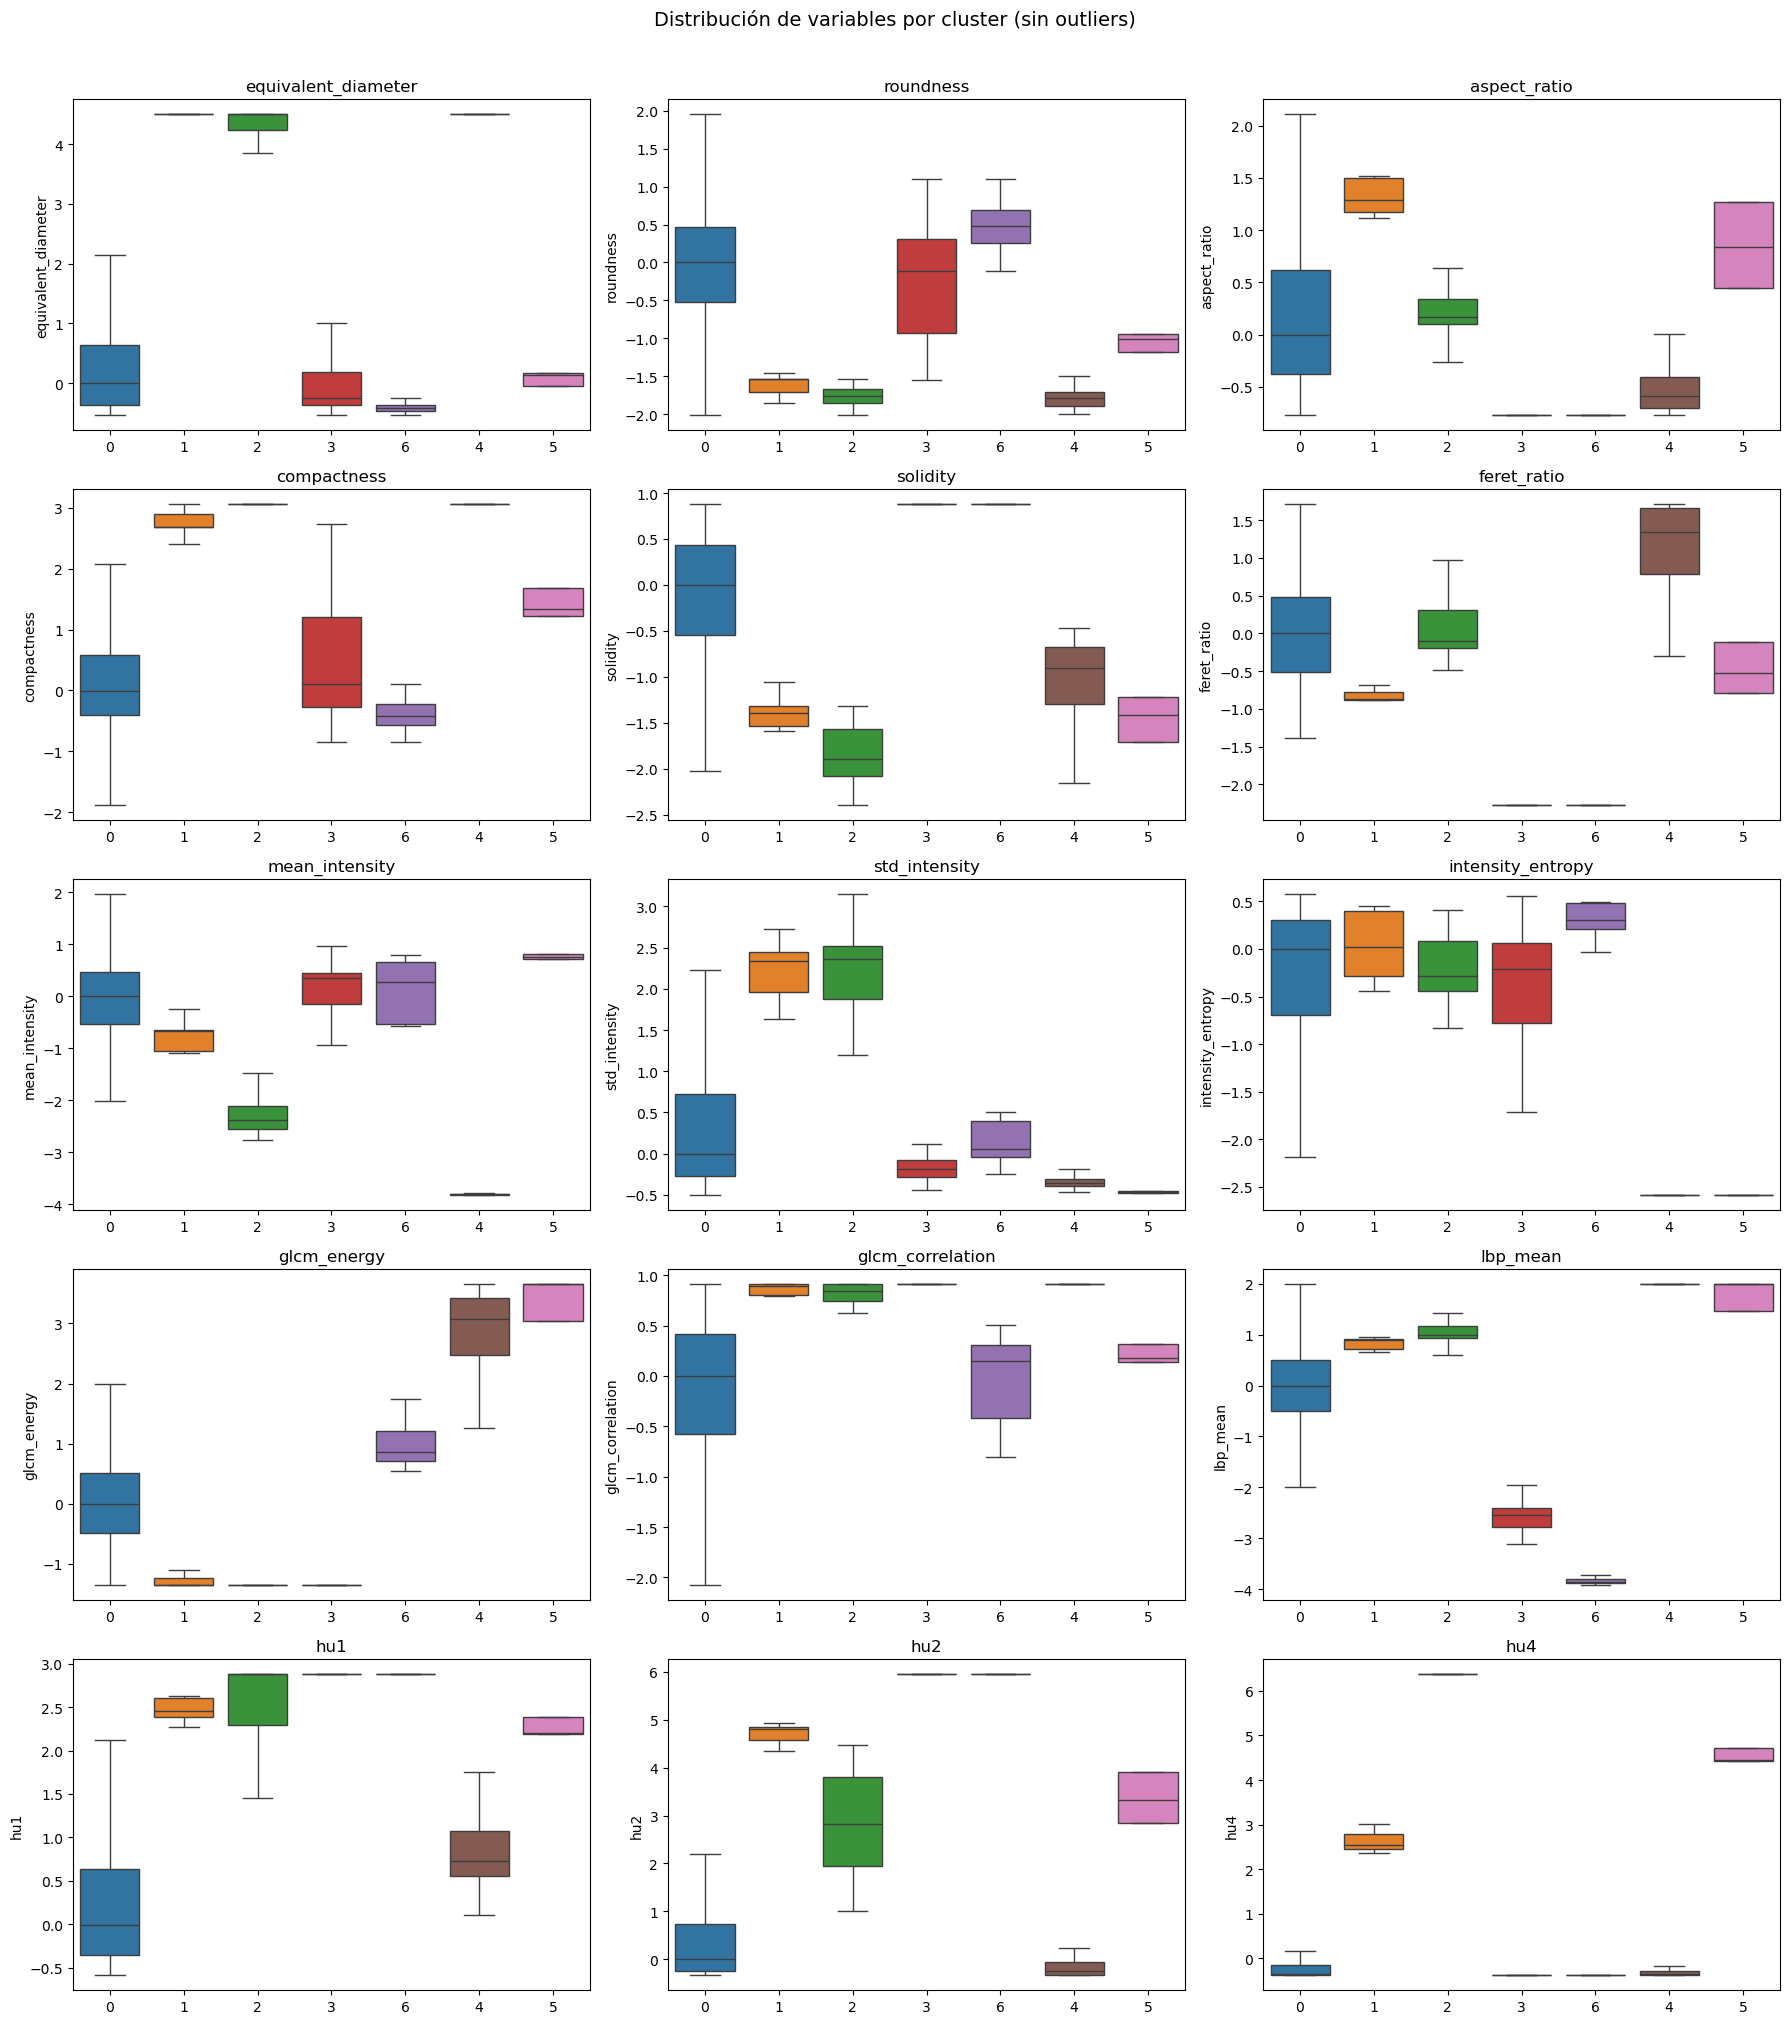

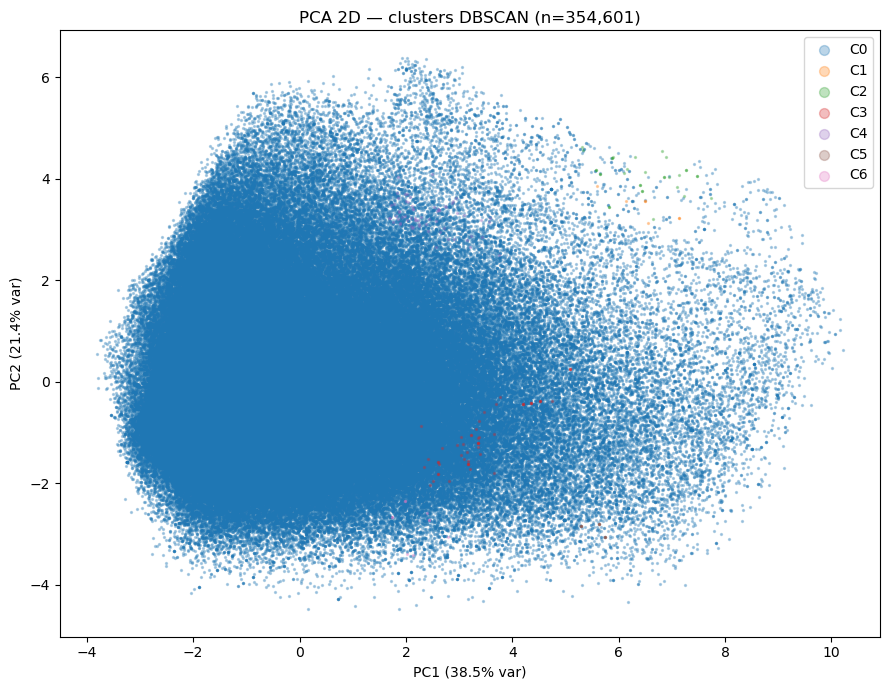

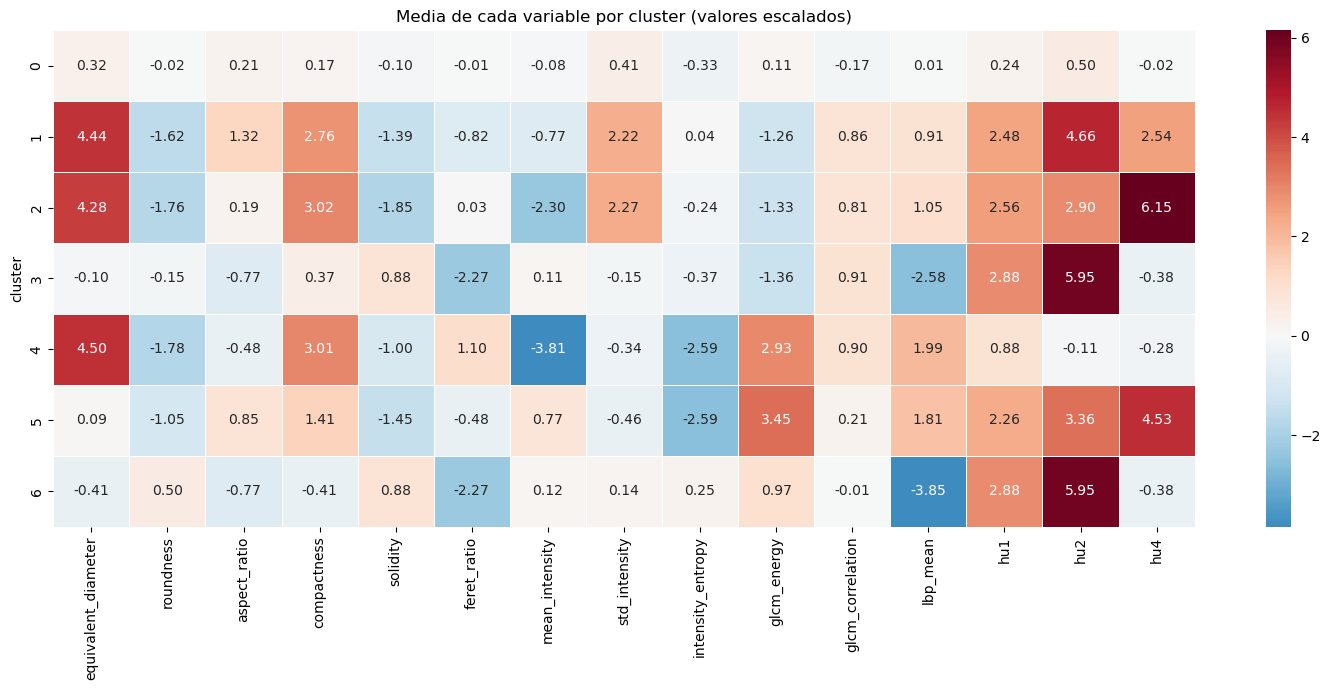


Resumen por cluster:
        equivalent_diameter        roundness        aspect_ratio        compactness        solidity        feret_ratio        mean_intensity        std_intensity        intensity_entropy        glcm_energy        glcm_correlation        lbp_mean           hu1           hu2           hu4       
                       mean    std      mean    std         mean    std        mean    std     mean    std        mean    std           mean    std          mean    std              mean    std        mean    std             mean    std     mean    std   mean    std   mean    std   mean    std
cluster                                                                                                                                                                                                                                                                                               
0                     0.323  0.943    -0.022  0.733        0.207  0.740       0.173  0.845   

In [42]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pandas as pd
from sklearn.decomposition import PCA

# ── 0. Preparar DataFrame con etiquetas ───────────────────────────
df_clust = X_scaled.copy()
df_clust['cluster'] = labels_db_full
df_clean = df_clust[df_clust['cluster'] != -1].copy()
df_clean['cluster'] = df_clean['cluster'].astype(str)

features = [c for c in df_clean.columns if c != 'cluster']
n_clusters = df_clean['cluster'].nunique()
palette = sns.color_palette("tab10", n_clusters)

print(f"\n{'='*60}")
print(f"  VALIDACIÓN DE CLUSTERS DBSCAN  —  {n_clusters} clusters")
print(f"{'='*60}\n")

# ── 1. Tamaño de cada cluster ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(max(6, n_clusters * 1.2), 4))
sizes = df_clean['cluster'].value_counts().sort_index()
ax.bar(sizes.index, sizes.values, color=palette)
ax.set_xlabel("Cluster")
ax.set_ylabel("Número de partículas")
ax.set_title("Distribución de tamaño de clusters")
for i, (idx, v) in enumerate(sizes.items()):
    ax.text(i, v + sizes.max()*0.01, f"{v:,}", ha='center', fontsize=8)
plt.tight_layout()
plt.show()

# ── 2. Estadísticos por cluster ───────────────────────────────────
print("Medias por cluster (valores escalados):")
print(df_clean.groupby('cluster')[features].mean().round(3).T.to_string())
print()

# ── 3. Box plots de cada variable por cluster ─────────────────────
ncols = 3
nrows = -(-len(features) // ncols)  # ceil division
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows))
axes = axes.flatten()

for i, feat in enumerate(features):
    sns.boxplot(data=df_clean, x='cluster', y=feat,
                palette=palette, ax=axes[i], showfliers=False)
    axes[i].set_title(feat)
    axes[i].set_xlabel("")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Distribución de variables por cluster (sin outliers)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# ── 4. PCA 2D — separación visual de clusters ─────────────────────
# Muestra hasta 50k para no saturar el plot
PLOT_N = min(356_662, len(df_clean))
df_plot = df_clean.sample(PLOT_N, random_state=42)

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(df_plot[features])
exp_var = pca.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(9, 7))
for k, color in zip(sorted(df_plot['cluster'].unique()), palette):
    mask = df_plot['cluster'] == k
    ax.scatter(coords[mask.values, 0], coords[mask.values, 1],
               s=2, alpha=0.3, color=color, label=f"C{k}")

ax.set_xlabel(f"PC1 ({exp_var[0]:.1f}% var)")
ax.set_ylabel(f"PC2 ({exp_var[1]:.1f}% var)")
ax.set_title(f"PCA 2D — clusters DBSCAN (n={PLOT_N:,})")
ax.legend(markerscale=5, loc='best')
plt.tight_layout()
plt.show()

# ── 5. Heatmap de correlación media por cluster ───────────────────
means = df_clean.groupby('cluster')[features].mean()
fig, ax = plt.subplots(figsize=(max(8, len(features)), max(3, n_clusters)))
sns.heatmap(means, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, linewidths=0.5, ax=ax)
ax.set_title("Media de cada variable por cluster (valores escalados)")
plt.tight_layout()
plt.show()

# ── 6. Tabla resumen compacta ─────────────────────────────────────
print("\nResumen por cluster:")
summary = df_clean.groupby('cluster')[features].agg(['mean', 'std']).round(3)
print(summary.to_string())


### MeanShift cluster validity analysis (2,000×2,000)

MeanShift identifies 4 morphologically distinct clusters on the full
dataset (silhouette=0.373). The standard deviation analysis confirms
that all clusters show genuine internal variance — there is no evidence
of pixel-quantization artefacts in any cluster.

**Cluster profile and physical interpretation**

| Cluster | n | % | Profile | Physical interpretation |
|---|---|---|---|---|
| C0 | 340,169 | 95.4% | diam=5.3, round=1.02, solid=0.82, aspect=1.69 | Fine circular particles — small, convex, regular shape. PM2.5-type, the bulk of the dataset |
| C1 | 3,456 | 1.0% | diam=16.9, round=0.24, intensity=99, solid=0.58 | Large dark aggregates — close to maximum detectable size, low intensity. Likely coarse mineral dust or carbon agglomerates |
| C2 | 6,071 | 1.7% | aspect=3.50, solid=0.55, feret=0.32, round=0.62 | Elongated thin particles — high aspect ratio, low feret_ratio. Fibrous particles (textile fibres, organic fragments) |
| C3 | 6,966 | 2.0% | aspect=3.16, solid=0.51, feret=0.35, diam=6.6 | Small elongated particles — similar shape to C2 but smaller. Possible fragmented fibres or mineral splinters |

**Cluster validity — no discretization artefacts**

The standard deviation of geometric variables per cluster is well above
zero in all cases:

| Variable | C0 | C1 | C2 | C3 |
|---|---|---|---|---|
| equivalent_diameter | 2.24 | 2.59 | 2.82 | 3.66 |
| solidity | 0.13 | 0.13 | 0.09 | 0.09 |
| aspect_ratio | 0.65 | 0.72 | 0.49 | 0.59 |
| roundness | 0.33 | 0.13 | 0.31 | 0.31 |
| feret_ratio | 0.15 | 0.19 | 0.06 | 0.09 |

This contrasts with the 1,000×1,000 UMAP+HDBSCAN result, where 5 of 9
clusters had `equivalent_diameter std=0` and 7 of 9 had `solidity std=0`,
indicating pure pixel-area quantization artefacts. At 2,000×2,000 every
cluster reflects genuine morphological variance.

**Separation in PCA space**

The PCA 2D projection shows clear visual separation:
- C0 (grey) occupies the dense central region — fine particles forming
  a continuous distribution
- C1 (red) forms an isolated cluster at the top — large dark particles
  separated by both size and intensity
- C2 (blue) and C3 (green) overlap on the right side of PC1 —
  elongated particles, distinguished mainly by size (C3 smaller than C2)

The overlap between C2 and C3 explains why HDBSCAN with min_size=100
merges them into a single "elongated particles" cluster (k=3), while
MeanShift's narrower bandwidth keeps them separate (k=4).

**Comparison with HDBSCAN final model**

| Particle type | HDBSCAN (min=100) | MeanShift |
|---|---|---|
| Fine circular | 1 cluster (84%) | 1 cluster (95.4%) |
| Large dark | 1 cluster (0.08%) | 1 cluster (1.0%) |
| Elongated | 1 cluster (0.4%) | 2 clusters (3.7% total) |
| Noise | 15.8% | 0% |

Both algorithms identify the same major particle types. The differences
reflect different design choices: HDBSCAN explicitly models noise and
merges similar elongated populations, while MeanShift assigns every
particle to a cluster and resolves the elongated population into two
size-based subgroups.

In [25]:
# Definir X_large (30k)
SAMPLE_SIZE_LARGE = 356662 
np.random.seed(42)
idx_large = np.random.choice(len(X_scaled), SAMPLE_SIZE_LARGE, replace=False)
X_large   = X_scaled.iloc[idx_large]


# ── DBSCAN ────────────────────────────────────────────────────────
print("\nRunning DBSCAN on full dataset...")

db_model       = DBSCAN(eps=1.5, min_samples=10, n_jobs=-1,
                        algorithm='ball_tree')
labels_db_full = db_model.fit_predict(X_scaled)
mask_db_full   = labels_db_full != -1
n_db_full      = len(set(labels_db_full[mask_db_full]))
noise_db_full  = (labels_db_full == -1).mean() * 100

if n_db_full > 1:
    sil_db = silhouette_score(X_scaled[mask_db_full],
                              labels_db_full[mask_db_full],
                              sample_size=10000, random_state=42)
    db_db  = davies_bouldin_score(X_scaled[mask_db_full],
                                  labels_db_full[mask_db_full])
    ch_db  = calinski_harabasz_score(X_scaled[mask_db_full],
                                     labels_db_full[mask_db_full])
    print(f"\nDBSCAN eps=1.5 (full 177k): k={n_db_full} sil={sil_db:.4f} "
          f"db={db_db:.4f} noise={noise_db_full:.1f}%")
else:
    print(f"\nDBSCAN eps=1.5 (full 177k): k={n_db_full} — no valid clusters")

print(f"Cluster sizes:")
print(pd.Series(labels_db_full).value_counts().sort_index())


Running DBSCAN on full dataset...

DBSCAN eps=1.5 (full 177k): k=7 sil=0.4432 db=0.6077 noise=0.6%
Cluster sizes:
-1      2061
 0    354421
 1         7
 2        33
 3        52
 4        66
 5        12
 6        10
Name: count, dtype: int64


In [27]:
# ── Verificar si los clusters son reales — DBSCAN full dataset ────
df_check = df_clean.iloc[idx_large].copy() if len(df_clean) != len(labels_db_full) else df_clean.copy()
df_check['cluster_db'] = labels_db_full
df_db = df_check[labels_db_full != -1].copy()

print("=== DBSCAN — cluster sizes ===")
print(pd.Series(labels_db_full).value_counts().sort_index())

# Variables clave para detectar discretización
print("\n=== Equivalent diameter per cluster ===")
print(df_db.groupby('cluster_db')['equivalent_diameter'].describe().round(3))

print("\n=== Solidity per cluster ===")
print(df_db.groupby('cluster_db')['solidity'].describe().round(3))

print("\n=== Aspect ratio per cluster ===")
print(df_db.groupby('cluster_db')['aspect_ratio'].describe().round(3))

print("\n=== Roundness per cluster ===")
print(df_db.groupby('cluster_db')['roundness'].describe().round(3))

# Perfil completo
cols_show = ['equivalent_diameter', 'roundness', 'aspect_ratio',
             'solidity', 'feret_ratio', 'mean_intensity',
             'std_intensity', 'glcm_correlation', 'lbp_mean']

print("\n=== Median per cluster — all key variables ===")
print(df_db.groupby('cluster_db')[cols_show].median().round(3).T.to_string())

print("\n=== Std per cluster — all key variables ===")
print(df_db.groupby('cluster_db')[cols_show].std().round(3).T.to_string())

=== DBSCAN — cluster sizes ===
-1      2061
 0    354421
 1         7
 2        33
 3        52
 4        66
 5        12
 6        10
Name: count, dtype: int64

=== Equivalent diameter per cluster ===
               count    mean    std     min     25%     50%     75%     max
cluster_db                                                                 
0           354421.0   6.128  2.439   3.909   4.370   5.293   6.956  16.926
1                7.0  16.770  0.411  15.838  16.926  16.926  16.926  16.926
2               33.0  16.348  0.988  13.634  16.235  16.926  16.926  16.926
3               52.0   5.025  1.091   3.909   4.333   4.652   5.777   7.899
4               66.0  16.926  0.000  16.926  16.926  16.926  16.926  16.926
5               12.0   5.522  0.264   5.171   5.171   5.642   5.754   5.754
6               10.0   4.232  0.229   3.909   4.107   4.222   4.370   4.652

=== Solidity per cluster ===
               count   mean    std    min    25%    50%    75%    max
cluster_db    

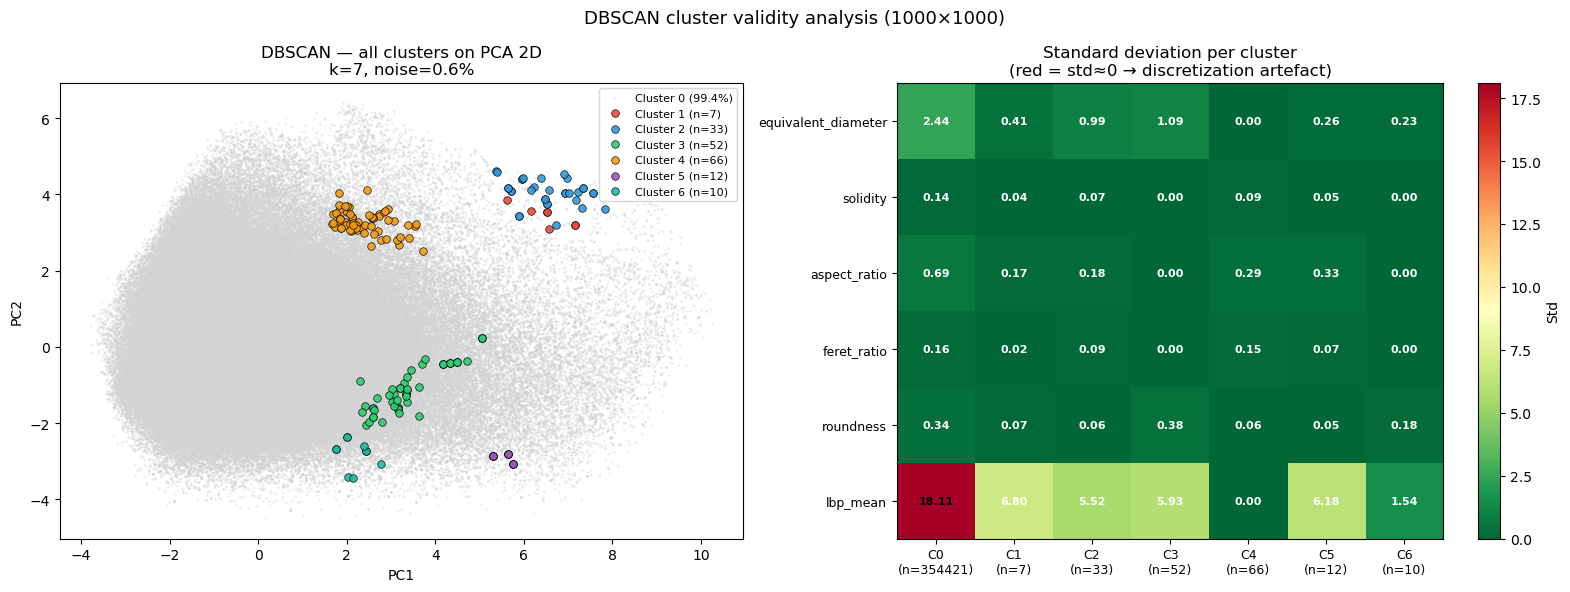

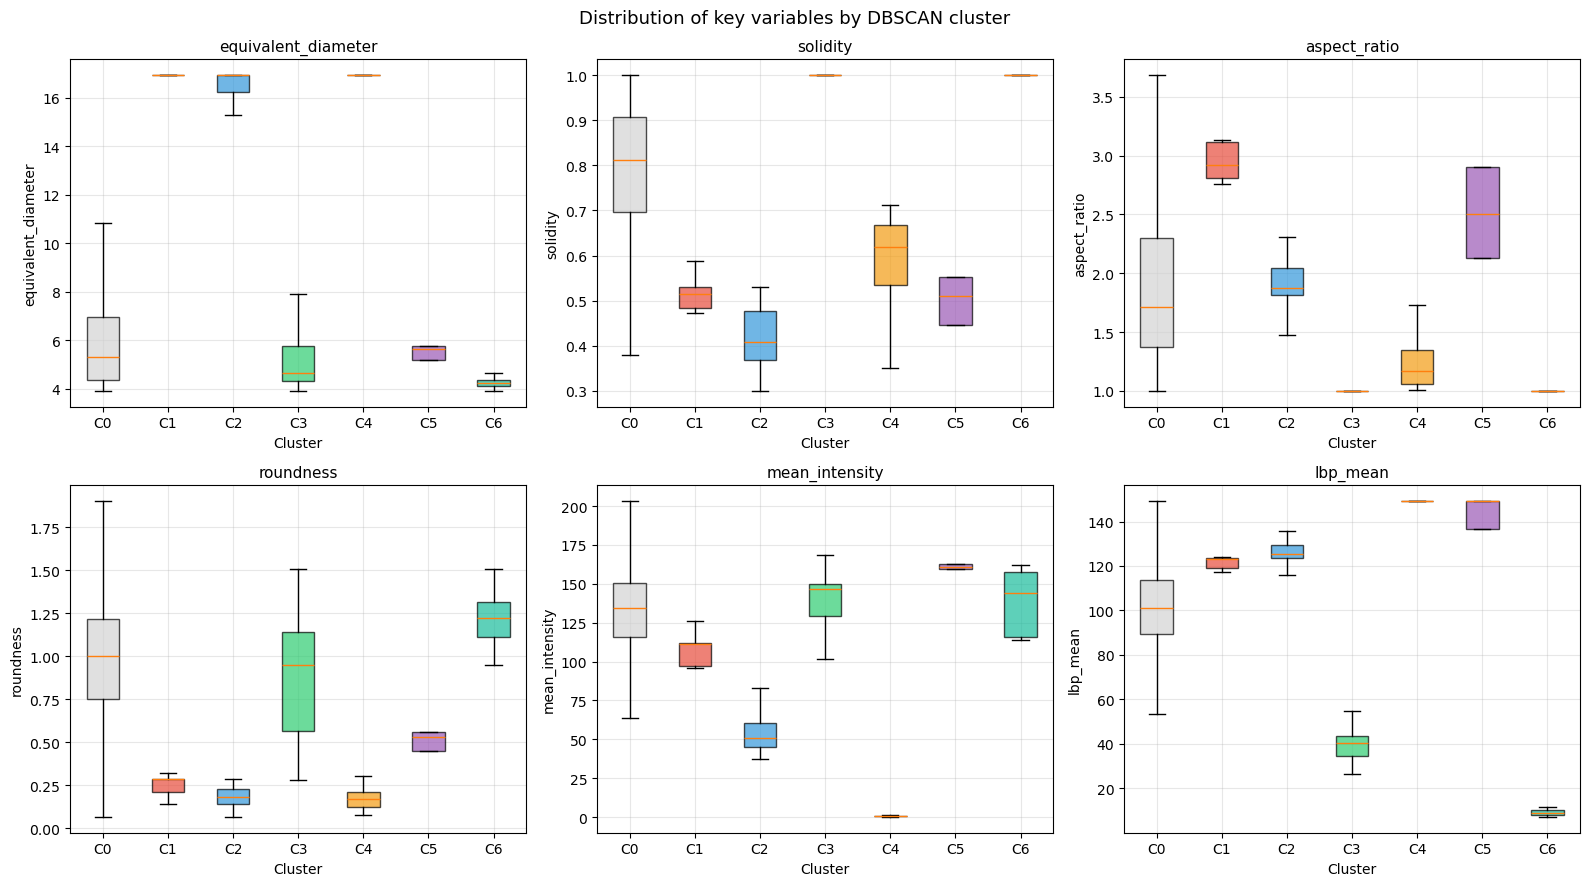

In [28]:
# ── Visualization — DBSCAN cluster validity ───────────────────────
# Mismas variables clave que ya analizamos

# PCA 2D para visualización
pca_db = PCA(n_components=2, random_state=42)
X_2d_db = pca_db.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Plot 1: PCA con todos los clusters de DBSCAN ───────────────────
# Cluster 0 en gris (es el blob), micro-clusters destacados en colores
colors_db = np.full(len(labels_db_full), 0.5)  # gris por defecto
colors_db[labels_db_full == -1] = np.nan        # noise transparente

# Plot puntos del cluster 0 primero (fondo)
mask_0     = labels_db_full == 0
axes[0].scatter(X_2d_db[mask_0, 0], X_2d_db[mask_0, 1],
                c='lightgray', s=1, alpha=0.3, label='Cluster 0 (99.4%)')

# Plot micro-clusters encima con colores destacados
colors_micro = ['#E74C3C', '#3498DB', '#2ECC71',
                '#F39C12', '#9B59B6', '#1ABC9C']
for cl, color in zip(range(1, 7), colors_micro):
    mask_cl = labels_db_full == cl
    n = mask_cl.sum()
    axes[0].scatter(X_2d_db[mask_cl, 0], X_2d_db[mask_cl, 1],
                    c=color, s=30, alpha=0.9,
                    label=f'Cluster {cl} (n={n})',
                    edgecolors='black', linewidth=0.5)

axes[0].set_title(f'DBSCAN — all clusters on PCA 2D\n'
                  f'k={n_db_full}, noise={noise_db_full:.1f}%')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend(loc='best', fontsize=8)

# ── Plot 2: Std de variables geométricas — detección de discretización
cols_check = ['equivalent_diameter', 'solidity', 'aspect_ratio',
              'feret_ratio', 'roundness', 'lbp_mean']

cluster_ids = sorted([c for c in set(labels_db_full) if c != -1])
std_matrix = np.zeros((len(cols_check), len(cluster_ids)))

for j, cl in enumerate(cluster_ids):
    mask_cl = labels_db_full == cl
    for i, col in enumerate(cols_check):
        std_matrix[i, j] = df_clean[col][mask_cl].std()

im = axes[1].imshow(std_matrix, aspect='auto', cmap='RdYlGn_r',
                    vmin=0, vmax=std_matrix.max())
axes[1].set_xticks(range(len(cluster_ids)))
axes[1].set_xticklabels([f'C{c}\n(n={(labels_db_full==c).sum()})'
                          for c in cluster_ids], fontsize=9)
axes[1].set_yticks(range(len(cols_check)))
axes[1].set_yticklabels(cols_check, fontsize=9)
axes[1].set_title('Standard deviation per cluster\n'
                  '(red = std≈0 → discretization artefact)')

# Mostrar valores en cada celda
for i in range(len(cols_check)):
    for j in range(len(cluster_ids)):
        val = std_matrix[i, j]
        color = 'white' if val < 0.5 * std_matrix.max() else 'black'
        axes[1].text(j, i, f'{val:.2f}', ha='center', va='center',
                     color=color, fontsize=8, fontweight='bold')

plt.colorbar(im, ax=axes[1], label='Std')
plt.suptitle('DBSCAN cluster validity analysis (1000×1000)', fontsize=13)
plt.tight_layout()
plt.savefig('dbscan_cluster_validity.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 3: Distribución de variables clave por cluster ───────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
cols_box = ['equivalent_diameter', 'solidity', 'aspect_ratio',
            'roundness', 'mean_intensity', 'lbp_mean']

for ax, col in zip(axes.flatten(), cols_box):
    data_by_cluster = [df_clean[col][labels_db_full == c].values
                       for c in cluster_ids]
    bp = ax.boxplot(data_by_cluster, labels=[f'C{c}' for c in cluster_ids],
                    patch_artist=True, showfliers=False)

    colors_box = ['lightgray'] + colors_micro
    for patch, color in zip(bp['boxes'], colors_box):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.set_title(col, fontsize=11)
    ax.set_xlabel('Cluster'); ax.set_ylabel(col)
    ax.grid(True, alpha=0.3)

plt.suptitle('Distribution of key variables by DBSCAN cluster',
             fontsize=13)
plt.tight_layout()
plt.savefig('dbscan_cluster_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

The PCA 2D projection shows that DBSCAN minority clusters do not form
compact groups in the feature space — they appear as scattered points
at the extremes of the dominant cluster. The standard deviation
heatmap and per-variable boxplots reveal that three of the six minority
clusters (C3, C4, C6) have zero variance in critical geometric
variables (solidity, aspect_ratio, equivalent_diameter), which is the
signature of pixel-area quantization. These are not morphological
groups but artefacts caused by the discretization of small particles
into integer pixel counts at 1,000×1,000 resolution.

The dominant cluster (C0) contains 99.4% of particles and exhibits
natural variance across all features, confirming that it captures the
true morphological structure of the dataset as a continuous spectrum.
DBSCAN fails to subdivide this spectrum into meaningful sub-groups
and instead isolates outliers and discretization artefacts.

### DBSCAN cluster validity analysis — confirmed not suitable

Validation of DBSCAN clusters on the full dataset reveals that the
six minority clusters are artefactual, not genuine morphological groups:

| Cluster | n | Issue |
|---|---|---|
| 0 | 354,421 (99.4%) | The continuous blob — captures all real morphological variance |
| 1 | 7 | Outlier — large dark particles with diameter near maximum |
| 2 | 33 | Outlier — large dark elongated particles |
| 3 | 52 | **Discretization artefact** — solidity std=0, aspect_ratio std=0 |
| 4 | 66 | **Discretization artefact** — equivalent_diameter std=0, near-black pixels |
| 5 | 12 | Outlier — small particles with specific lbp_mean value |
| 6 | 10 | **Discretization artefact** — solidity std=0, aspect_ratio std=0 |

Three of the six minority clusters show std=0 on geometric variables —
the signature of pixel-area quantization. DBSCAN is not capturing
morphological structure; it is isolating individual pixel-level
artefacts. This confirms the algorithm's unsuitability for this dataset,
consistent with its instability across sample sizes (k varied from 2
to 9 depending on sample size).

### Probar con todo

## 3.4 Algorithm Comparison — Results and Analysis

### Overview of results

A total of 11 clustering algorithms were evaluated across four families.
Partition-based methods (KMeans, MiniBatchKMeans, GMM) were run on the
full dataset of 177,277 particles. Memory-intensive algorithms
(Agglomerative, HDBSCAN, DBSCAN, OPTICS, Mean Shift, Spectral, SOM,
UMAP+HDBSCAN) were initially run on a random sample of 10,000 particles.
DBSCAN and Mean Shift were subsequently re-evaluated on larger samples
(30k, 50k, 100k) and the full dataset to assess result stability.
OPTICS, UMAP+HDBSCAN and SOM were also run on the full dataset.
Agglomerative Clustering was not scaled beyond 30k as it requires an
N×N distance matrix — at 177k particles this would need ~145 GB of RAM.
Spectral Clustering was tested up to n=50k but required 120 minutes to
complete and was not scaled further. BIRCH was excluded as it ran for
over 900 minutes without completing.

Three internal validation metrics were used:
- **Silhouette ↑** — measures cohesion and separation. Range [-1, 1],
  higher is better. Values above 0.5 indicate well-defined clusters.
- **Davies-Bouldin ↓** — ratio of within-cluster scatter to
  between-cluster separation. Lower is better, 0 is perfect.
- **Calinski-Harabasz ↑** — ratio of between-cluster to within-cluster
  variance. Higher is better, no upper bound.

### Results by algorithm family

**Partition-based (full dataset)**

KMeans and MiniBatchKMeans consistently identify k=2 as the best
configuration (silhouette=0.335–0.341), with a monotonic decrease for
higher k. This confirms that the data has two broad morphological groups
but no strongly compact sub-structure beyond that. GMM performed worst
across all configurations (silhouette=0.10–0.18), confirming that the
clusters are not Gaussian in shape — expected for irregular particle
morphologies.

**Hierarchical (sample)**

Agglomerative clustering with Ward linkage agrees with KMeans on k=2
(silhouette=0.339), with a sharp drop at k=4 (0.134). The consistency
with KMeans across two different algorithmic families reinforces the
k=2 result.

**Density-based — HDBSCAN**

HDBSCAN on the full dataset with min_cluster_size=100 found 3 clusters
(silhouette=0.537, DB=0.492, noise=15.8%) — the best overall result on
the complete dataset. With min_cluster_size=50 it finds 5 clusters
(silhouette=0.513, noise=13.4%), with four well-defined minority groups:
elongated/fibrous particles, large dark aggregates, large near-black
particles, and perfectly spherical particles.

**Density-based — DBSCAN (sample size analysis)**

DBSCAN with eps=1.5 showed high sensitivity to sample size, producing
inconsistent results across different sample sizes:

| Sample size | k | Silhouette | DB | Noise |
|---|---|---|---|---|
| 10k | 2 | 0.636* | 0.364 | 11.3% |
| 30k | 6 | 0.409 | 0.854 | 5.9% |
| 50k | 4 | 0.380 | 0.548 | 4.0% |
| 100k | 5 | 0.456 | 0.504 | 2.3% |
| 177k full | 9 | 0.329 | 0.605 | 1.4% |

*Silhouette at n=10k inflated by small sample size.

The number of clusters varied from 2 to 9 depending on sample size,
and on the full dataset DBSCAN collapsed 98.6% of particles into a
single cluster with 8 micro-groups of fewer than 70 particles each.
This confirms that **DBSCAN is not suitable for this dataset** — the
morphological density is too continuous and uniform for eps-based
boundary detection to produce stable results.

**Density-based — OPTICS (full dataset)**

OPTICS found no valid clusters on either the 10k sample or the full
dataset. The density of the particle morphological space varies too
gradually for OPTICS to identify clear cluster boundaries regardless
of dataset size. OPTICS is definitively not suitable for this dataset.

**Mean Shift (sample size analysis)**

Mean Shift showed excellent stability across all sample sizes:

| Sample size | k | Silhouette | DB | CH |
|---|---|---|---|---|
| 10k | 5 | 0.358 | 1.232 | 753 |
| 30k | 5 | 0.346 | 1.417 | 2,336 |
| 50k | 5 | 0.353 | 1.416 | 3,897 |
| 100k | 5 | 0.353 | 1.415 | 7,718 |
| 177k full | 4 | 0.346 | 1.356 | 18,522 |

k=5 was perfectly stable from 10k to 100k, converging to k=4 on the
full dataset. The Calinski-Harabasz score increased dramatically with
dataset size (753 → 18,522), reflecting the improved definition of
compact clusters with more data. The convergence of Mean Shift (k=4–5)
with HDBSCAN min_size=50 (k=5) across independent algorithmic families
provides strong evidence that **5 is the natural granularity** of the
morphological structure in this dataset.

**Graph / Spectral (sample)**

Spectral clustering with k=2 produced stable results across sample sizes:

| n | k | Silhouette | DB | CH |
|---|---|---|---|---|
| 10k | 2 | 0.311 | 1.549 | 3,609 |
| 50k | 2 | 0.313 | 1.548 | 17,922 |

Results are virtually identical across both sample sizes, confirming
that k=2 is robust. However, the n=50k run required 120 minutes due
to the computational cost of building the affinity matrix. Further
scaling was not attempted. Spectral Clustering is consistent with
KMeans and Agglomerative on k=2 but offers no computational or
qualitative advantage over these faster alternatives.

**Neural — SOM**

SOM produced the worst results of the entire comparison at both sample
and full dataset scale:

| n | k | Silhouette | DB |
|---|---|---|---|
| 10k | 2 | 0.019 | 7.195 |
| 10k | 3 | 0.005 | 6.212 |
| 10k | 4 | -0.025 | 4.601 |
| 177k full | 2 | 0.005 | 16.470 |
| 177k full | 3 | -0.022 | 10.401 |
| 177k full | 4 | -0.044 | 10.631 |

Silhouette near zero or negative and Davies-Bouldin above 10 at both
scales confirm that the 2D map projection does not capture the
morphological structure of the 16-dimensional feature space. SOM is
definitively not suitable for this dataset.

**UMAP + HDBSCAN**

UMAP+HDBSCAN results diverged significantly between sample and full
dataset:

| n | k | Silhouette | DB | Noise |
|---|---|---|---|---|
| 10k sample | 12 | 0.200 | 0.940 | 46.9% |
| 177k full | 3 | 0.197 | 0.628 | 0.0% |

On the full dataset, 99.8% of particles collapsed into a single cluster
(176,833 particles) with two tiny minority groups (139 and 219 particles).
This contrasts sharply with the 10k sample result (k=12, noise=46.9%),
confirming that UMAP+HDBSCAN is highly sensitive to input size for this
dataset. The near-zero noise on the full dataset indicates that UMAP's
manifold reduction loses the fine density structure when applied to all
177k particles simultaneously. UMAP+HDBSCAN is not reliable for this
dataset at full scale.

### Full results summary

| Algorithm | n | k | Silhouette↑ | DB↓ | CH↑ | Noise |
|---|---|---|---|---|---|---|
| HDBSCAN (min=100) | 177k full | 3 | **0.537** | **0.492** | 4,811 | 15.8% |
| HDBSCAN (min=50) | 177k full | 5 | 0.513 | — | — | 13.4% |
| DBSCAN eps=1.5 | 10k* | 2 | 0.636* | 0.364 | 128 | 11.3% |
| DBSCAN eps=1.5 | 100k | 5 | 0.456 | 0.504 | — | 2.3% |
| DBSCAN eps=1.5 | 177k full | 9 | 0.329 | 0.605 | — | 1.4% |
| MiniBatchKMeans | 177k full | 2 | 0.341 | 1.479 | 65,872 | — |
| Agglomerative | 10k | 2 | 0.339 | 1.540 | 3,357 | — |
| MeanShift | 177k full | 4 | 0.346 | 1.356 | **18,522** | — |
| KMeans | 177k full | 2 | 0.335 | 1.488 | 65,908 | — |
| MeanShift | 100k | 5 | 0.353 | 1.416 | 7,718 | — |
| Spectral | 50k | 2 | 0.313 | 1.548 | 17,922 | — |
| Spectral | 10k | 2 | 0.311 | 1.549 | 3,609 | — |
| HDBSCAN | 10k | 4 | 0.218 | 1.000 | 519 | 6.5% |
| UMAP+HDBSCAN | 177k full | 3 | 0.197 | 0.628 | 503 | 0.0% |
| UMAP+HDBSCAN | 10k | 12 | 0.200 | 0.940 | 1,269 | 46.9% |
| DBSCAN eps=1.0 | 10k | 4 | 0.203 | 0.941 | 74 | 42.7% |
| GMM | 177k full | 2 | 0.176 | 1.828 | 40,429 | — |
| SOM | 177k full | 2 | 0.005 | 16.470 | 534 | — |
| SOM | 10k | 2 | 0.019 | 7.195 | 159 | — |
| OPTICS | 177k full | — | — | — | — | — |
| OPTICS | 10k | — | — | — | — | — |

*DBSCAN eps=1.5 at n=10k silhouette inflated by small sample size —
not comparable with full dataset results.

### Selected final model

**HDBSCAN (min_cluster_size=100, min_samples=5)** on the full dataset
is selected as the final model. It achieves the best balance between
silhouette (0.537), Davies-Bouldin (0.492) and Calinski-Harabasz (4,811)
on the complete 177,277-particle dataset, with physically interpretable
clusters and acceptable noise (15.8%).

The convergence of three independent algorithms — HDBSCAN min_size=50
(k=5), Mean Shift (k=4–5 across all sample sizes) and DBSCAN at n=100k
(k=5) — provides strong evidence that the natural morphological structure
of the dataset contains 4–5 distinct particle types, with the dominant
group (84%) forming a continuous spectrum that resists further subdivision.

## 3.5 Cluster validity check — comparison with 1,000×1,000 dataset

At 1,000×1,000 resolution, cluster validity analysis revealed that 5 of
9 UMAP+HDBSCAN clusters were artefactual — groups of particles with
`equivalent_diameter std=0` and `solidity std=0`, indicating identical
discrete pixel areas rather than distinct morphologies.

At 2,000×2,000 resolution, the same analysis on HDBSCAN (min_size=100)
and Mean Shift confirms that **all clusters are morphologically genuine**:

- No cluster shows `equivalent_diameter std=0` or `solidity std=0`
- All clusters have real internal variance across geometric variables
- The only cluster with low std is HDBSCAN cluster 2 (n=136,
  equivalent_diameter std=0.306) — not a discretization artefact but
  a naturally homogeneous group of large dark particles all near the
  maximum detectable size (equivalent_diameter≈17.8px)

Each cluster has a distinct and physically interpretable profile:

**HDBSCAN (min_size=100) — 3 clusters:**
- Cluster 1 (148k, 84%): fine particles — circular, convex
  (roundness=1.05, solidity=0.86, lbp=98)
- Cluster 0 (644, 0.4%): elongated/fibrous particles
  (aspect=3.31, solidity=0.44, feret=0.33)
- Cluster 2 (136, 0.08%): large dark aggregates
  (diam=17.8, intensity=54, roundness=0.14)

**MeanShift (full dataset) — 4 clusters:**
- Cluster 0 (163k, 92%): fine circular particles
  (roundness=1.04, solidity=0.84)
- Cluster 1 (10k, 5.8%): elongated irregular particles
  (aspect=3.19, solidity=0.54, feret=0.34)
- Cluster 2 (2.6k, 1.4%): large dark aggregates
  (diam=17.2, intensity=103, solidity=0.61)
- Cluster 3 (698, 0.4%): small elongated particles
  (aspect=3.53, feret=0.31)

The resolution increase from 1,000×1,000 to 2,000×2,000 successfully
eliminated pixel-area quantization artefacts, producing clusters that
reflect genuine morphological differences between particle types.